<a href="https://colab.research.google.com/github/vrhsr/retail-price-optimization-bigdata/blob/main/retail_price_optimization_bigdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade seaborn
!pip install dash

Requirement already up-to-date: seaborn in c:\users\dell\anaconda3\lib\site-packages (0.12.2)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv('F:/yercaud/correlated_retail_data.csv')

In [ ]:
print("Missing Values Before Handling:\n", df.isnull().sum())
print(df.dtypes)

Missing Values Before Handling:
 productid              0
product_name           0
product_category       0
month_year             0
qt                     0
unit_price             0
freight_price          0
product_name_length    0
product_description    0
product_photos_qty     0
product_weight_g       0
product_score          0
customers              0
weekday                0
weekend                0
holiday                0
month                  0
year                   0
s                      0
volume                 0
myntra_price           0
amazon_price           0
flipkart_price         0
ajio_price             0
meesho_price           0
myntra_rating          0
amazon_rating          0
flipkart_rating        0
ajio_rating            0
meesho_rating          0
customer_review        0
total_price            0
customers.1            0
dtype: int64
productid                int64
product_name            object
product_category        object
month_year              object
qt   

In [ ]:
price_columns = ['total_price', 'unit_price', 'freight_price', 'myntra_price', 'amazon_price',
                 'flipkart_price', 'ajio_price', 'meesho_price']
rating_columns = ['myntra_rating', 'amazon_rating', 'flipkart_rating', 'ajio_rating', 'meesho_rating']

# Round price columns to 2 decimal places
df[price_columns] = df[price_columns].round(2)

# Round rating columns to 1 decimal place
df[rating_columns] = df[rating_columns].round(1)

In [ ]:
print("\nDataset Summary:\n", df.describe())


Dataset Summary:
            productid             qt     unit_price  freight_price  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean    50000.500000       9.994080     453.369214      27.523482   
std     28867.657797       5.469763     709.913942      12.972470   
min         1.000000       1.000000      19.040000       5.000000   
25%     25000.750000       5.000000      46.970000      16.330000   
50%     50000.500000      10.000000      62.520000      27.540000   
75%     75000.250000      15.000000     561.180000      38.770000   
max    100000.000000      19.000000    2486.630000      50.000000   

       product_name_length  product_description  product_photos_qty  \
count        100000.000000        100000.000000       100000.000000   
mean              8.551930           124.283010            2.498400   
std               2.953373            43.353249            1.118217   
min               4.000000            50.000000            1.000000   
25% 

In [ ]:
df.head()

,productid,product_name,product_category,month_year,qt,unit_price,freight_price,product_name_length,product_description,product_photos_qty,...,ajio_price,meesho_price,myntra_rating,amazon_rating,flipkart_rating,ajio_rating,meesho_rating,customer_review,total_price,customers.1
0,1,Novel,Books,2022-09,6,25.28,18.29,5,187,4,...,24.85,24.02,2.6,2.6,2.5,2.5,2.6,Terrible experience.,25.28,C04807
1,2,Lipstick,Beauty,2022-11,10,47.06,10.28,8,70,1,...,44.74,45.81,2.9,3.0,3.0,2.9,2.9,"It's okay, nothing special.",47.06,C04950
2,3,Refrigerator,Home Appliances,2023-11,11,553.52,43.83,12,155,4,...,516.46,529.02,4.4,4.4,4.2,4.3,4.5,Great product! Highly recommended.,553.52,C03144
3,4,Foundation,Beauty,2024-06,13,56.19,6.37,10,77,3,...,52.78,55.26,3.3,3.3,3.1,3.3,3.3,Neither good nor bad.,56.19,C06392
4,5,Foundation,Beauty,2024-05,15,39.57,17.81,10,63,3,...,35.48,36.80,4.1,4.2,4.0,3.9,4.2,"It's okay, nothing special.",39.57,C06780


In [ ]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Function to analyze sentiment
def get_sentiment(text):
    sentiment_score = sia.polarity_scores(str(text))["compound"]
    if sentiment_score >= 0.05:
        return "Positive"
    elif sentiment_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
# Apply sentiment analysis
df["sentiment"] = df["customer_review"].apply(get_sentiment)

In [ ]:
# Display sentiment distribution
print(df["sentiment"].value_counts())

Positive    40078
Negative    32039
Neutral     27883
Name: sentiment, dtype: int64


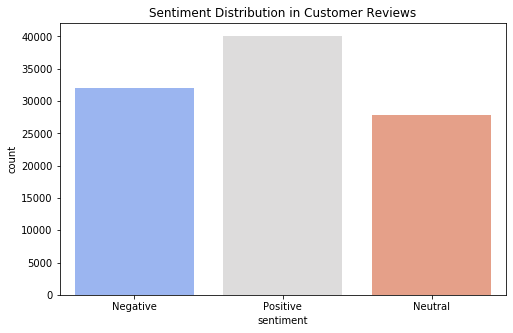

In [ ]:
# Visualize sentiment distribution
plt.figure(figsize=(8,5))
sns.countplot(x=df["sentiment"], palette="coolwarm")
plt.title("Sentiment Distribution in Customer Reviews")
plt.show()

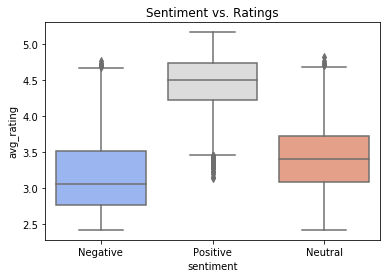

In [ ]:
# Correlation between sentiment and ratings
df["avg_rating"] = df[["meesho_rating", "ajio_rating", "flipkart_rating", "amazon_rating", "myntra_rating"]].mean(axis=1)
sns.boxplot(x=df["sentiment"], y=df["avg_rating"], palette="coolwarm")
plt.title("Sentiment vs. Ratings")
plt.show()

In [ ]:
# Save new dataset with sentiment labels
df.to_csv('F:/yercaud/correlated_retail_dataaa.csv', index=False)

In [ ]:
print("Dataset with sentiment labels saved as: F:/yercaud/correlated_retail_dataaa.csv")

Dataset with sentiment labels saved as: F:/yercaud/correlated_retail_dataaa.csv


In [ ]:
file_path = "F:/yercaud/correlated_retail_dataaa.csv"
df = pd.read_csv(file_path)

In [ ]:
df["avg_rating"] = df[["meesho_rating", "ajio_rating", "flipkart_rating", "amazon_rating", "myntra_rating"]].mean(axis=1)

In [ ]:
# Convert sentiment to numeric values for correlation analysis
sentiment_map = {"Positive": 1, "Neutral": 0, "Negative": -1}
df["sentiment_score"] = df["sentiment"].map(sentiment_map)

In [ ]:
def calculate_optimized_price():
    product_name = input("Enter product name: ")
    product_data = df[df["product_name"].str.lower() == product_name.lower()]

    if product_data.empty:
        return f"Product '{product_name}' not found in the dataset."

    # Calculate the average competitor price
    avg_price = product_data[["meesho_price", "ajio_price", "flipkart_price", "amazon_price", "myntra_price"]].mean(axis=1).values[0]

    # Get sentiment and rating factors
    sentiment_factor = product_data["sentiment_score"].values[0]
    rating_factor = product_data["avg_rating"].values[0] / 5

    # Pricing weights (adjustable)
    alpha, beta = 0.05, 0.03
    optimized_price = avg_price * (1 + alpha * sentiment_factor + beta * rating_factor)

    return f"Suggested optimized price for '{product_name}': ₹{round(optimized_price, 2)}"

# Run the function with user input
print(calculate_optimized_price())


Enter product name: Lipstick
Suggested optimized price for 'Lipstick': ₹42.59


In [ ]:
# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Retail Price Optimization Dashboard", style={'textAlign': 'center'}),

    dcc.Dropdown(
        id='product-dropdown',
        options=[{'label': p, 'value': p} for p in df['product_name'].unique()],
        placeholder="Select a product",
        style={'width': '50%'}
    ),

    html.H3(id='optimal-price-output', style={'margin-top': '20px'}),

    dcc.Graph(id='price-comparison-graph'),
    dcc.Graph(id='sentiment-distribution-graph')
])

In [ ]:
@app.callback(
    [Output('optimal-price-output', 'children'),
     Output('price-comparison-graph', 'figure'),
     Output('sentiment-distribution-graph', 'figure')],
    Input('product-dropdown', 'value')
)
def update_dashboard(product_name):
    if not product_name:
        return "", {}, {}

    product_data = df[df['product_name'] == product_name]

    avg_competitor_price = product_data[['meesho_price', 'ajio_price', 'flipkart_price', 'amazon_price', 'myntra_price']].mean(axis=1).values[0]
    sentiment_factor = product_data['sentiment_score'].mean()

    if sentiment_factor < 0:
        optimized_price = avg_competitor_price * 0.95
    elif sentiment_factor > 0:
        optimized_price = avg_competitor_price * 1.05
    else:
        optimized_price = avg_competitor_price

    optimal_price_text = f"Suggested Optimal Price: ₹{optimized_price:.2f}"

    price_comparison_fig = px.bar(
        product_data.melt(id_vars=['product_name'], value_vars=['meesho_price', 'ajio_price', 'flipkart_price', 'amazon_price', 'myntra_price']),
        x='variable', y='value', text='value', title='Competitor Price Comparison',
        labels={'variable': 'Platform', 'value': 'Price (₹)'}, color='variable'
    )

    sentiment_fig = px.histogram(
        df[df['product_name'] == product_name], x='sentiment', title='Sentiment Distribution',
        labels={'sentiment': 'Customer Sentiment'}, color='sentiment'
    )

    return optimal_price_text, price_comparison_fig, sentiment_fig


In [ ]:
if __name__ == '__main__':
    app.run_server(debug=True)

C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.



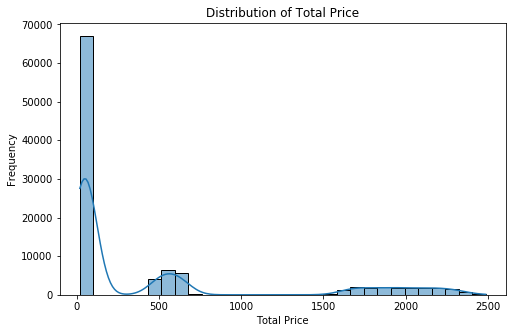

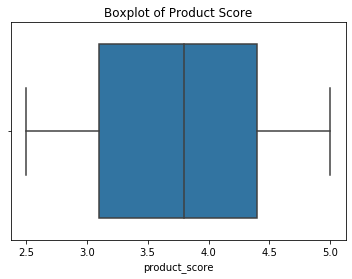

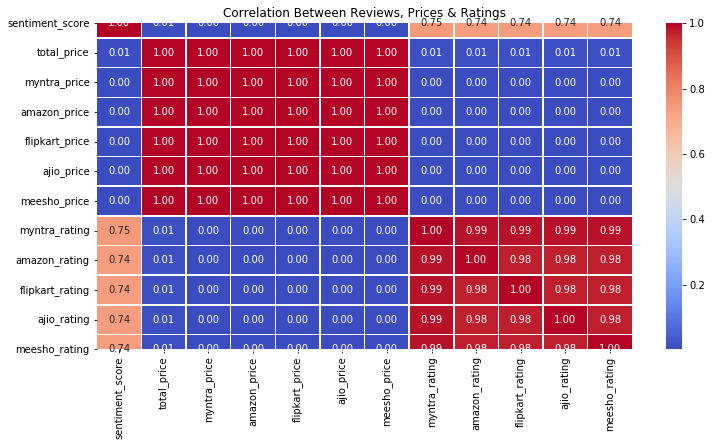

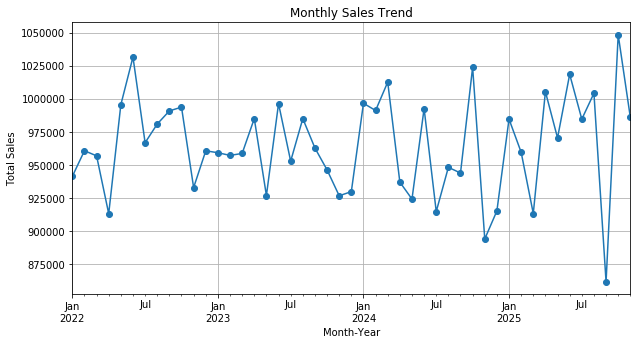

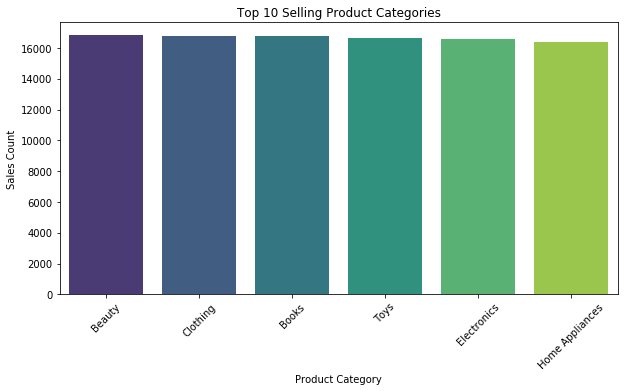

Number of Outliers in Total Price: 0


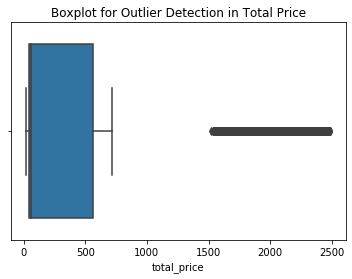

In [ ]:
from textblob import TextBlob
# Visualizing Distributions
# Histogram of total price
plt.figure(figsize=(8,5))
sns.histplot(df['total_price'], bins=30, kde=True)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot of product score
plt.figure(figsize=(6,4))
sns.boxplot(x=df['product_score'])
plt.title("Boxplot of Product Score")
plt.show()

# Correlation Analysis

# 🔹 Convert Customer Reviews to Sentiment Scores
def get_sentiment(text):
    analysis = TextBlob(str(text))  # Convert to string in case of NaN
    return analysis.sentiment.polarity  # Returns value between -1 (negative) to +1 (positive)

df["sentiment_score"] = df["customer_review"].apply(get_sentiment)

# 🔹 Select Relevant Columns for Correlation
correlation_features = [
    "sentiment_score", "total_price",
    "myntra_price", "amazon_price", "flipkart_price", "ajio_price", "meesho_price",
    "myntra_rating", "amazon_rating", "flipkart_rating", "ajio_rating", "meesho_rating"
]

# 🔹 Compute Correlation Matrix
correlation_matrix = df[correlation_features].corr()

# 🔹 Visualize Correlation Matrix
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Reviews, Prices & Ratings")
plt.show()
### STEP 4: Customer Behavior Analysis ###

# Monthly sales trend
df['month_year'] = pd.to_datetime(df['month_year'])
monthly_sales = df.groupby(df['month_year'].dt.to_period("M"))['total_price'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Top-selling product categories
plt.figure(figsize=(10,5))
top_categories = df['product_category'].value_counts().nlargest(10)
sns.barplot(x=top_categories.index, y=top_categories.values, palette="viridis")
plt.title("Top 10 Selling Product Categories")
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Sales Count")
plt.show()

### STEP 5: Outlier Detection ###
from scipy.stats import zscore

# Identify outliers in total_price
df['z_score'] = np.abs(zscore(df['total_price']))
outliers = df[df['z_score'] > 3]

print(f"Number of Outliers in Total Price: {outliers.shape[0]}")

# Boxplot for total price outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_price'])
plt.title("Boxplot for Outlier Detection in Total Price")
plt.show()

# Remove outliers (Optional)
df_cleaned = df[df['z_score'] <= 3]
df_cleaned.drop(columns=['z_score'], inplace=True)  # Drop z-score column


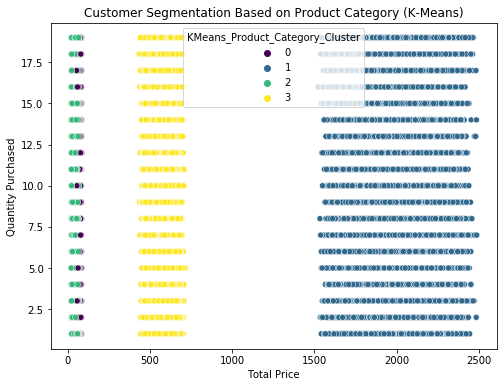

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load cleaned dataset
df = pd.read_csv("F:/yercaud/correlated_retail_dataaa.csv")

# Standardizing the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Product_Category_Cluster'] = kmeans.fit_predict(scaled_features)

# Visualizing K-Means Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['total_price'], y=df['qt'], hue=df['KMeans_Product_Category_Cluster'], palette='viridis')
plt.title("Customer Segmentation Based on Product Category (K-Means)")
plt.xlabel("Total Price")
plt.ylabel("Quantity Purchased")
plt.show()



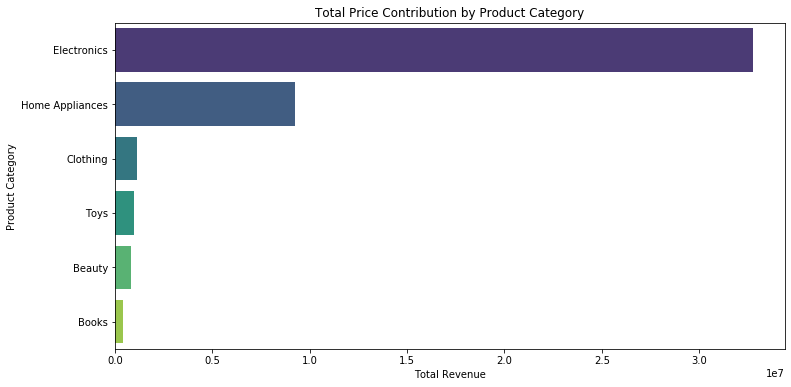

In [ ]:
# Aggregate total price by product category
category_revenue = df.groupby("product_category")["total_price"].sum().reset_index()

# Sort values for better visualization
category_revenue = category_revenue.sort_values(by="total_price", ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x="total_price", y="product_category", data=category_revenue, palette="viridis")

# Labels and title
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.title("Total Price Contribution by Product Category")

# Show plot
plt.show()

In [ ]:
# Count total customers for each product category
category_customers = df.groupby("product_category")["customers"].sum()

# Display the result
print(category_customers)

product_category
Beauty             4214372
Books              4195844
Clothing           4162351
Electronics        4158386
Home Appliances    4115074
Toys               4176176
Name: customers, dtype: int64


C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

C:\Users\DELL\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.



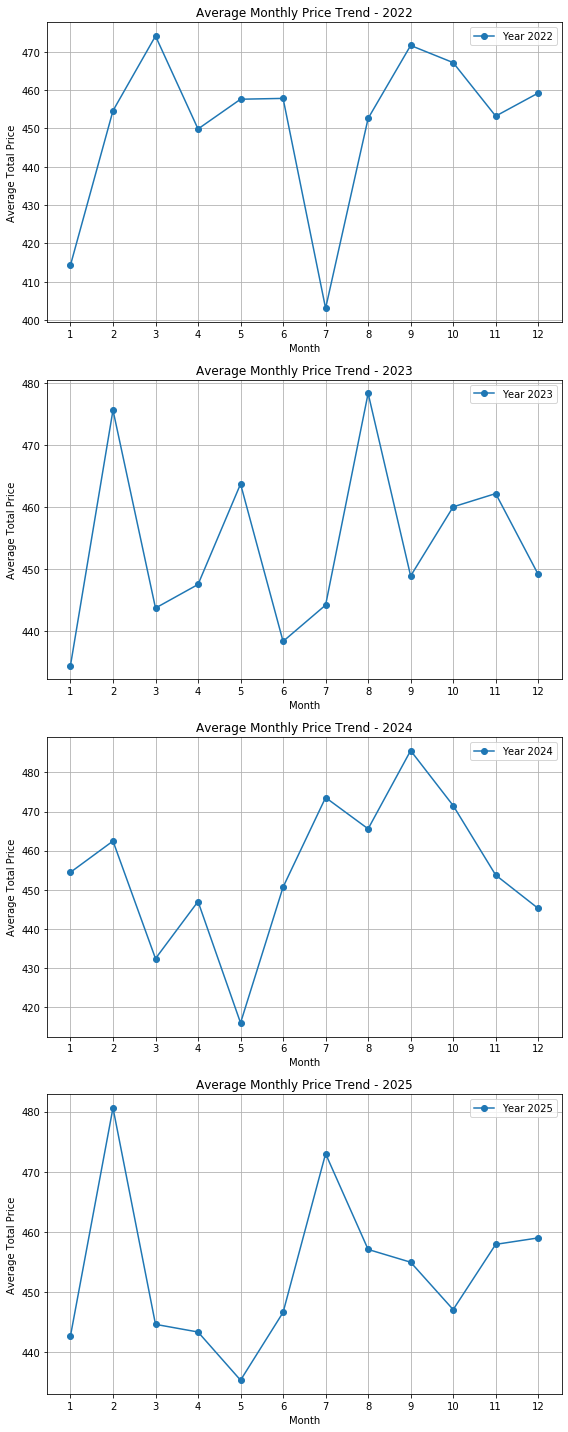

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month_year to datetime
df['month_year'] = pd.to_datetime(df['month_year'])

# Compute average price per month
monthly_price = df.groupby(['year', 'month'])['total_price'].mean().reset_index()

# Get unique years
unique_years = sorted(df['year'].unique())

# Create subplots for each year
fig, axes = plt.subplots(len(unique_years), 1, figsize=(8, 5 * len(unique_years)))

# If there's only one year, make axes a list for consistency
if len(unique_years) == 1:
    axes = [axes]

# Generate a separate line chart for each year
for i, year in enumerate(unique_years):
    yearly_data = monthly_price[monthly_price['year'] == year]
    axes[i].plot(yearly_data['month'], yearly_data['total_price'], marker='o', linestyle='-', label=f'Year {year}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Average Total Price')
    axes[i].set_title(f'Average Monthly Price Trend - {year}')
    axes[i].set_xticks(yearly_data['month'])
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Select relevant features
X = df[['month', 'year', 'weekend', 'weekday']]
y = df['total_price']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=50, min_samples_split=5, random_state=42)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predict optimal prices
df['predicted_price_linear'] = linear_model.predict(scaler.transform(X))
df['predicted_price_rf'] = rf_model.predict(scaler.transform(X))

# Print original and predicted prices
print(df[['month', 'year', 'predicted_price_linear', 'predicted_price_rf']].head())


   month  year  predicted_price_linear  predicted_price_rf
0     12  2024              467.265130          504.684658
1     12  2024              463.693264          419.306144
2      5  2022              445.181468          478.576097
3      3  2025              451.676665          442.958353
4      8  2022              454.379537          508.872639


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Convert necessary columns to appropriate data types
df['qt'] = pd.to_numeric(df['qt'], errors='coerce')
df['total_price'] = pd.to_numeric(df['total_price'], errors='coerce')

# Selecting relevant features for prediction
features = ['myntra_price', 'amazon_price', 'flipkart_price', 'ajio_price', 'meesho_price',
            'myntra_rating', 'amazon_rating', 'flipkart_rating', 'ajio_rating', 'meesho_rating']
X = df[features]
y = df['total_price']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=50, min_samples_split=5, random_state=42)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

#Function to Predict & Visualize
def predict_and_visualize(product_name):
    product_data = df[df['product_name'].str.lower() == product_name.lower()]
    if product_data.empty:
        print("Product not found in dataset!")
        return
    #Calculate Average Prices & Ratings
    avg_original_price = product_data['total_price'].mean()
    avg_competitor_prices = {
        "Myntra": product_data['myntra_price'].mean(),
        "Amazon": product_data['amazon_price'].mean(),
        "Flipkart": product_data['flipkart_price'].mean(),
        "Ajio": product_data['ajio_price'].mean(),
        "Meesho": product_data['meesho_price'].mean()
    }

    avg_competitor_ratings = {
        "Myntra": product_data['myntra_rating'].mean(),
        "Amazon": product_data['amazon_rating'].mean(),
        "Flipkart": product_data['flipkart_rating'].mean(),
        "Ajio": product_data['ajio_rating'].mean(),
        "Meesho": product_data['meesho_rating'].mean()
    }

    #Predict Optimized Price
    X_product = product_data[features].mean().values.reshape(1, -1)
    X_product_scaled = scaler.transform(X_product)

    predicted_price_linear = linear_model.predict(X_product_scaled)[0]
    predicted_price_rf = rf_model.predict(X_product_scaled)[0]

    #Print Results
    print("\n**Predicted Prices:**")
    print(f"Optimized Price (Linear Regression): {round(predicted_price_linear, 2)}")
    print(f"Optimized Price (Random Forest): {round(predicted_price_rf, 2)}")

    print("\n**Original & Competitor Prices:**")
    for key, value in avg_competitor_prices.items():
        print(f"{key} Price: {round(value, 2)}")
    print(f"Original Price: {round(avg_original_price, 2)}")

    print("\n**Average Competitor Ratings:**")
    for key, value in avg_competitor_ratings.items():
        print(f"{key} Rating: {round(value, 1)}")
    plt.show()

#Get User Input & Predict
product_name = input("Enter product name: ")
predict_and_visualize(product_name)


Enter product name: Refrigerator

**Predicted Prices:**
Optimized Price (Linear Regression): 564.24
Optimized Price (Random Forest): 557.33

**Original & Competitor Prices:**
Myntra Price: 524.97
Amazon Price: 524.8
Flipkart Price: 525.0
Ajio Price: 524.61
Meesho Price: 524.45
Original Price: 564.16

**Average Competitor Ratings:**
Myntra Rating: 3.8
Amazon Rating: 3.8
Flipkart Rating: 3.8
Ajio Rating: 3.8
Meesho Rating: 3.8


C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\base.py:451: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names




Model Performance: Mean Absolute Error (MAE) = 5.74

Enter the Product Name: Headphones

Recommended Optimized Price for 'Headphones': ₹1885.58


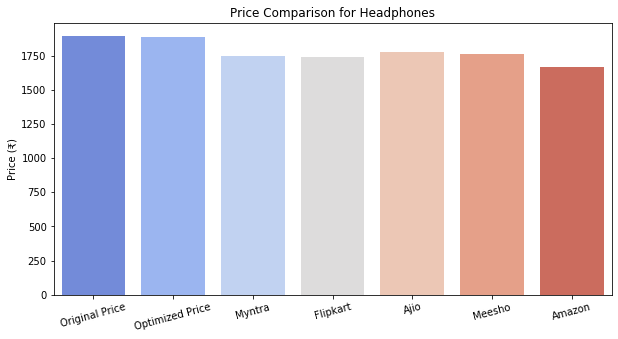

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load dataset
file_path = "F:/yercaud/correlated_retail_dataaa.csv"
data = pd.read_csv(file_path)

# Select required columns
columns_needed = ["unit_price", "myntra_price", "flipkart_price", "ajio_price", "meesho_price", "amazon_price", "product_name"]
data = data[columns_needed]

# Define features (X) and target variable (y)
X = data[["myntra_price", "flipkart_price", "ajio_price", "meesho_price", "amazon_price"]]  # Competitor prices
y = data["unit_price"]  # Original price

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate model performance
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("\nModel Performance: Mean Absolute Error (MAE) =", round(mae, 2))

# Function to get optimized price and visualize price comparison
def get_optimized_price(product_name):
    product_data = data[data["product_name"].str.lower() == product_name.lower()]

    if product_data.empty:
        print("Product not found in the dataset!")
        return

    # Extract competitor prices
    comp_prices = product_data[["myntra_price", "flipkart_price", "ajio_price", "meesho_price", "amazon_price"]]
    original_price = product_data["unit_price"].values[0]

    # Convert NumPy array to DataFrame with correct feature names
    comp_prices_df = pd.DataFrame(comp_prices.values, columns=X.columns)

    # Predict optimized price
    optimized_price = model.predict(comp_prices_df)[0]

    # Print recommended price
    print(f"\nRecommended Optimized Price for '{product_name}': ₹{round(optimized_price, 2)}")

    # Visualization: Price Comparison
    price_labels = ["Original Price", "Optimized Price", "Myntra", "Flipkart", "Ajio", "Meesho", "Amazon"]
    price_values = [original_price, optimized_price] + list(comp_prices.values[0])

    plt.figure(figsize=(10,5))
    sns.barplot(x=price_labels, y=price_values, palette="coolwarm")

    plt.title(f"Price Comparison for {product_name}")
    plt.ylabel("Price (₹)")
    plt.xticks(rotation=15)
    plt.show()


# Get user input and show optimized price with visualization
product_name = input("\nEnter the Product Name: ")
get_optimized_price(product_name)


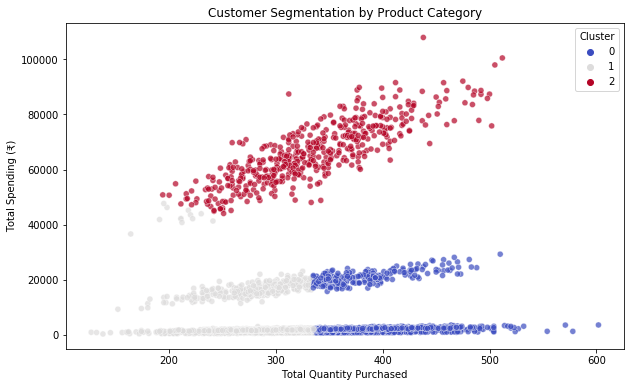

Customer Segmentation Completed ✅ - Results saved to 'customer_segmentation.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
file_path = "F:/yercaud/correlated_retail_dataaa.csv"
df = pd.read_csv(file_path)

# Select features for clustering
columns_needed = ["product_category", "customers", "qt", "total_price"]  # 'qt' = quantity purchased
df = df[columns_needed]

# Aggregate customer purchases by category
customer_segmentation = df.groupby(["product_category", "customers"]).agg(
    {"qt": "sum", "total_price": "sum"}
).reset_index()

# Scale the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_segmentation[["qt", "total_price"]])

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # 3 clusters (can be adjusted)
customer_segmentation["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualizing Customer Segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=customer_segmentation["qt"],
    y=customer_segmentation["total_price"],
    hue=customer_segmentation["Cluster"],
    palette="coolwarm",
    alpha=0.7
)
plt.title("Customer Segmentation by Product Category")
plt.xlabel("Total Quantity Purchased")
plt.ylabel("Total Spending (₹)")
plt.legend(title="Cluster")
plt.show()

# Save the segmented data
customer_segmentation.to_csv("F:/yercaud/customer_segmentation.csv", index=False)

print("Customer Segmentation Completed ✅ - Results saved to 'customer_segmentation.csv'")


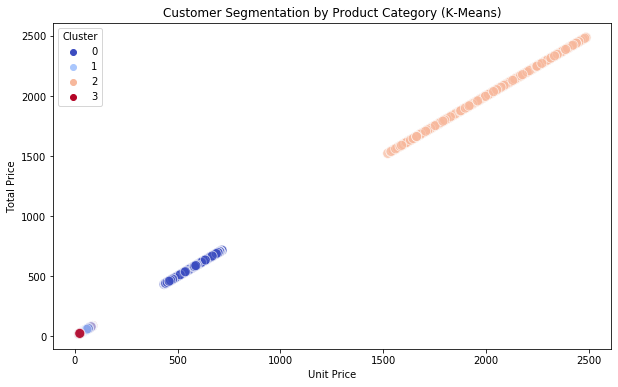


Cluster Centers:
[[4.50367925e+00 2.51075008e+02 3.09743799e+02 3.09743799e+02
  9.97338219e+00]
 [9.92210087e-01 3.76152626e+02 4.65871948e+01 4.65871948e+01
  1.00746868e+01]
 [3.00000000e+00 2.50625964e+02 1.97421338e+03 1.97421338e+03
  9.97980955e+00]
 [1.00718182e+00 1.25774577e+02 4.67758750e+01 4.67758750e+01
  9.95141478e+00]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 🔹 Load Dataset
file_path = "F:/yercaud/correlated_retail_dataaa.csv"  # Change to your actual file path
df = pd.read_csv(file_path)

# 🔹 Ensure clean column names
df.columns = df.columns.str.strip().str.lower()

# 🔹 Select Relevant Features for Clustering
features = ["product_category", "customers", "unit_price", "total_price", "qt"]

# 🔹 Encode Categorical Data
label_encoder = LabelEncoder()
df["product_category"] = label_encoder.fit_transform(df["product_category"])

# 🔹 Extract Features
X = df[features]

# 🔹 Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Apply K-Means Clustering
num_clusters = 4  # You can adjust this based on the elbow method
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# 🔹 Visualizing Clusters (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["unit_price"], y=df["total_price"], hue=df["cluster"], palette="coolwarm", s=100, alpha=0.7)
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.title("Customer Segmentation by Product Category (K-Means)")
plt.legend(title="Cluster")
plt.show()

# 🔹 Display Cluster Centers
print("\nCluster Centers:")
print(scaler.inverse_transform(kmeans.cluster_centers_))



Model Performance: Mean Absolute Error (MAE) = 83.33

Enter Product Name: Lipstick
Enter Current Stock Level: 29


C:\Users\DELL\Anaconda3\lib\site-packages\sklearn\base.py:451: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



⚠️ Restock Needed: Predicted demand = 636 units, Stock Left = 29 units.


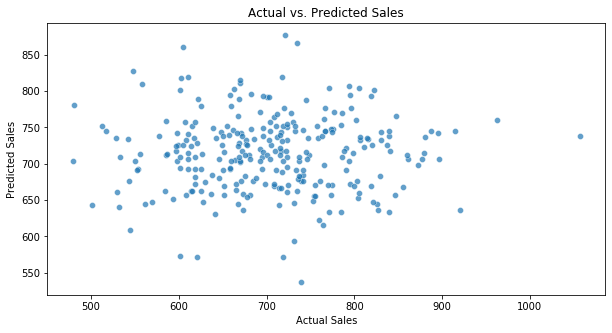

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load Dataset
file_path = "F:/yercaud/correlated_retail_dataaa.csv"
df = pd.read_csv(file_path)

# Selecting relevant features for demand prediction
columns_needed = ["product_name", "month_year", "qt", "unit_price"]
df = df[columns_needed]

# Convert month_year to datetime and extract numerical features
df["month_year"] = pd.to_datetime(df["month_year"])
df["year"] = df["month_year"].dt.year
df["month"] = df["month_year"].dt.month

# Aggregate sales data to find monthly demand patterns
sales_data = df.groupby(["product_name", "year", "month"]).agg({"qt": "sum"}).reset_index()

# Creating lag features (previous month sales)
sales_data["prev_month_sales"] = sales_data.groupby("product_name")["qt"].shift(1)
sales_data = sales_data.dropna()  # Drop first month entries (no previous data)

# Train-Test Split
X = sales_data[["prev_month_sales"]]
y = sales_data["qt"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Demand Prediction Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nModel Performance: Mean Absolute Error (MAE) = {round(mae, 2)}")

# Function to predict demand for next month
def predict_demand(product_name, current_stock):
    product_data = sales_data[sales_data["product_name"] == product_name]

    if product_data.empty:
        return f"Product '{product_name}' not found in dataset."

    last_month_sales = product_data["qt"].iloc[-1]  # Last available month's sales
    predicted_sales = model.predict(np.array([[last_month_sales]]))[0]  # Predict demand

    if predicted_sales > current_stock:
        return f"⚠️ Restock Needed: Predicted demand = {round(predicted_sales)} units, Stock Left = {current_stock} units."
    else:
        return f"✅ Stock is sufficient. Predicted demand = {round(predicted_sales)} units, Stock Left = {current_stock} units."

# Example Usage
product_name = input("\nEnter Product Name: ")
current_stock = int(input("Enter Current Stock Level: "))
print(predict_demand(product_name, current_stock))

# Visualization: Stock vs. Predicted Demand
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 🔹 Load the datasets
retail_data_path = "F:/yercaud/correlated_retail_data.csv"
inventory_data_path = "F:/yercaud/inventory_management_data.csv"

retail_data = pd.read_csv(retail_data_path)
inventory_data = pd.read_csv(inventory_data_path)

# 🔹 Merge datasets on product_name
merged_data = pd.merge(inventory_data, retail_data, on="product_name", how="inner")

# 🔹 Select relevant features for demand prediction
features = ["stock_left", "sales_last_month", "avg_monthly_sales"]
X = merged_data[features]
y = merged_data["demand_prediction"]

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Train RandomForest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔹 Predict Demand
y_pred = model.predict(X_test)

# 🔹 Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
print(f"\n📌 Model Performance: Mean Absolute Error (MAE) = {round(mae, 2)}")

# 🔹 Function to Get Inventory Recommendation
def inventory_recommendation(product_name):
    product = merged_data[merged_data["product_name"] == product_name]

    if product.empty:
        return "Product not found in inventory!"

    stock_left = product["stock_left"].values[0]
    predicted_demand = product["demand_prediction"].values[0]

    if stock_left < predicted_demand * 0.5:
        return f"⚠️ **Restock Needed!** Stock left: {stock_left}, Predicted Demand: {predicted_demand}"
    elif stock_left < predicted_demand:
        return f"🔄 **Monitor Stock Levels!** Stock left: {stock_left}, Predicted Demand: {predicted_demand}"
    else:
        return f"✅ **Stock is Sufficient!** Stock left: {stock_left}, Predicted Demand: {predicted_demand}"

# 🔹 Get Inventory Recommendation for a Sample Product
product_name = input("\nEnter Product Name for Inventory Check: ")
print(inventory_recommendation(product_name))

# 🔹 Visualization: Stock vs. Predicted Demand
plt.figure(figsize=(10, 6))
sns.barplot(x=merged_data["product_name"], y=merged_data["stock_left"], color="blue", label="Stock Left")
sns.barplot(x=merged_data["product_name"], y=merged_data["demand_prediction"], color="red", alpha=0.7, label="Predicted Demand")
plt.xticks(rotation=90)
plt.xlabel("Product Name")
plt.ylabel("Stock & Demand")
plt.title("Stock Levels vs. Predicted Demand")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
data = pd.DataFrame({
    'Name': [f'Student{i}' for i in range(1, 21)],
    'Age': np.random.randint(18, 25, 20),
    'Gender': np.random.choice(['Male', 'Female'], 20),
    'Grade': np.random.choice(['A', 'B', 'C', 'D'], 20),
    'Test_Score': np.random.randint(40, 101, 20),
    'Attendance (%)': np.random.randint(60, 101, 20),
    'Study_Hours': np.random.uniform(1, 10, 20).round(1),
    'Participation': np.random.choice(['Yes', 'No'], 20),
    'Projects_Completed': np.random.randint(1, 6, 20),
    'Satisfaction_Score': np.random.choice([1, 2, 3, 4, 5], 20)
})

<Figure size 1000x600 with 0 Axes>

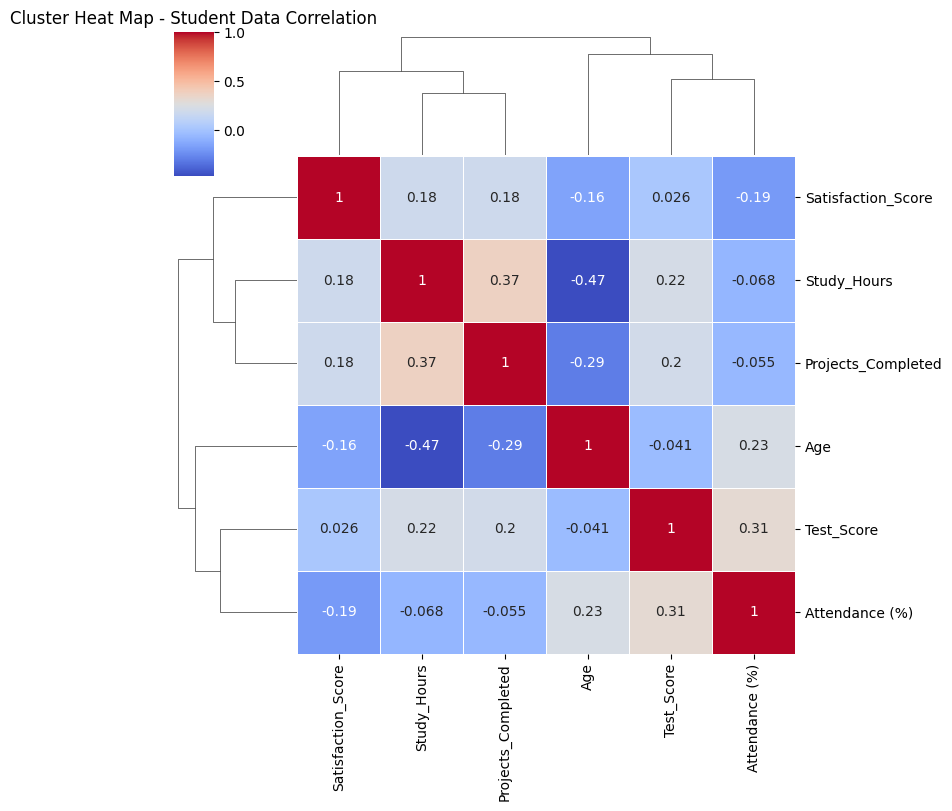

In [ ]:
numeric_columns = ['Age', 'Test_Score', 'Attendance (%)', 'Study_Hours', 'Projects_Completed', 'Satisfaction_Score']
corr_matrix = data[numeric_columns].corr()
plt.figure(figsize=(10, 6))
sns.clustermap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, figsize=(8, 8))
plt.title("Cluster Heat Map - Student Data Correlation")
plt.show()

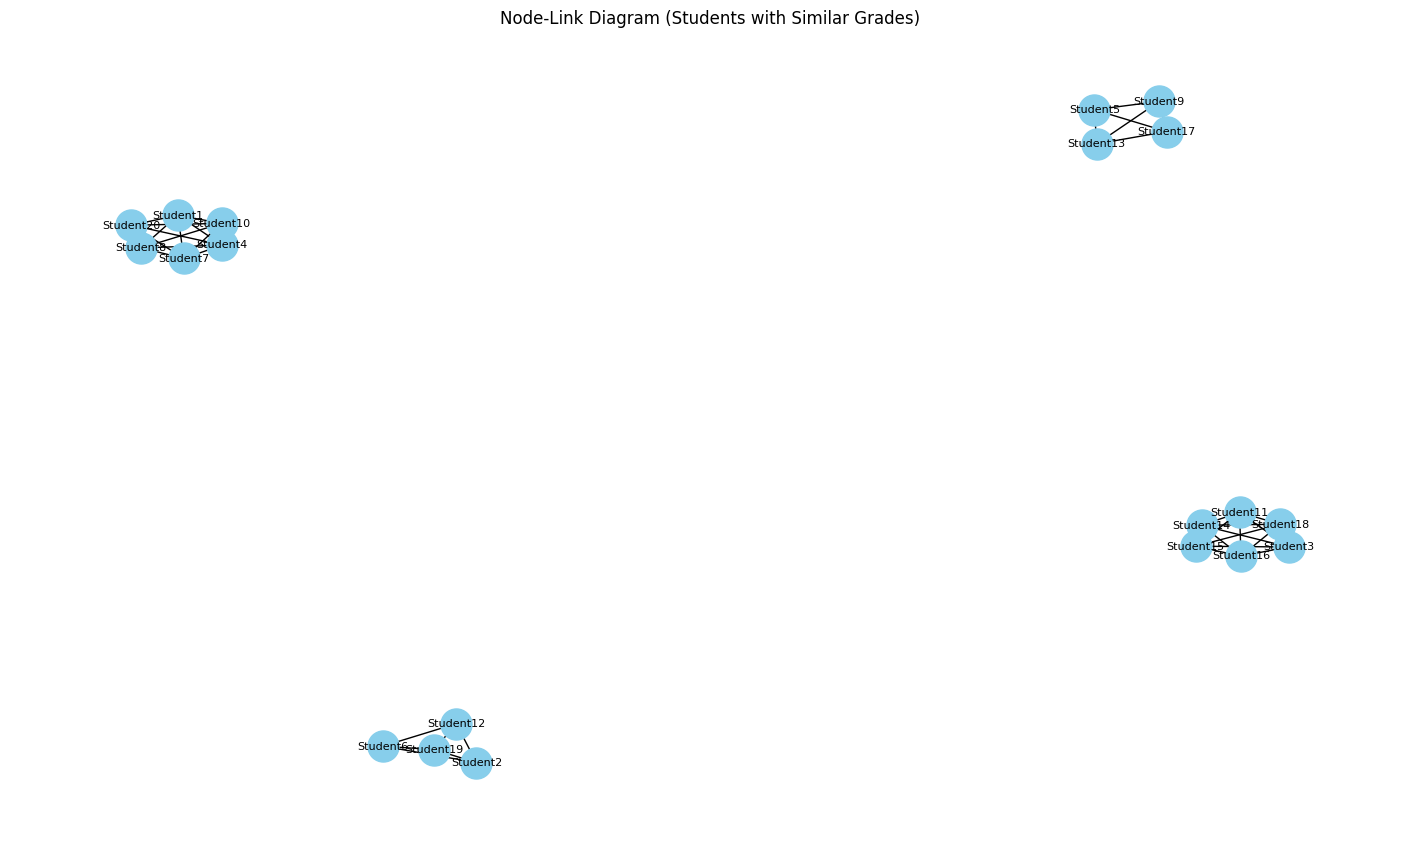

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
data = pd.DataFrame({
    'Name': [f'Student{i}' for i in range(1, 21)],
    'Age': np.random.randint(18, 25, 20),
    'Gender': np.random.choice(['Male', 'Female'], 20),
    'Grade': np.random.choice(['A', 'B', 'C', 'D'], 20),
    'Test_Score': np.random.randint(40, 101, 20),
    'Attendance (%)': np.random.randint(60, 101, 20),
    'Study_Hours': np.random.uniform(1, 10, 20).round(1),
    'Participation': np.random.choice(['Yes', 'No'], 20),
    'Projects_Completed': np.random.randint(1, 6, 20),
    'Satisfaction_Score': np.random.choice([1, 2, 3, 4, 5], 20)
})
G = nx.Graph()
for i, student1 in data.iterrows():
    G.add_node(student1['Name'])
    for j, student2 in data.iterrows():
        if i != j and student1['Grade'] == student2['Grade']:
            G.add_edge(student1['Name'], student2['Name'])
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=8, font_color='black')
plt.title("Node-Link Diagram (Students with Similar Grades)")
plt.show()

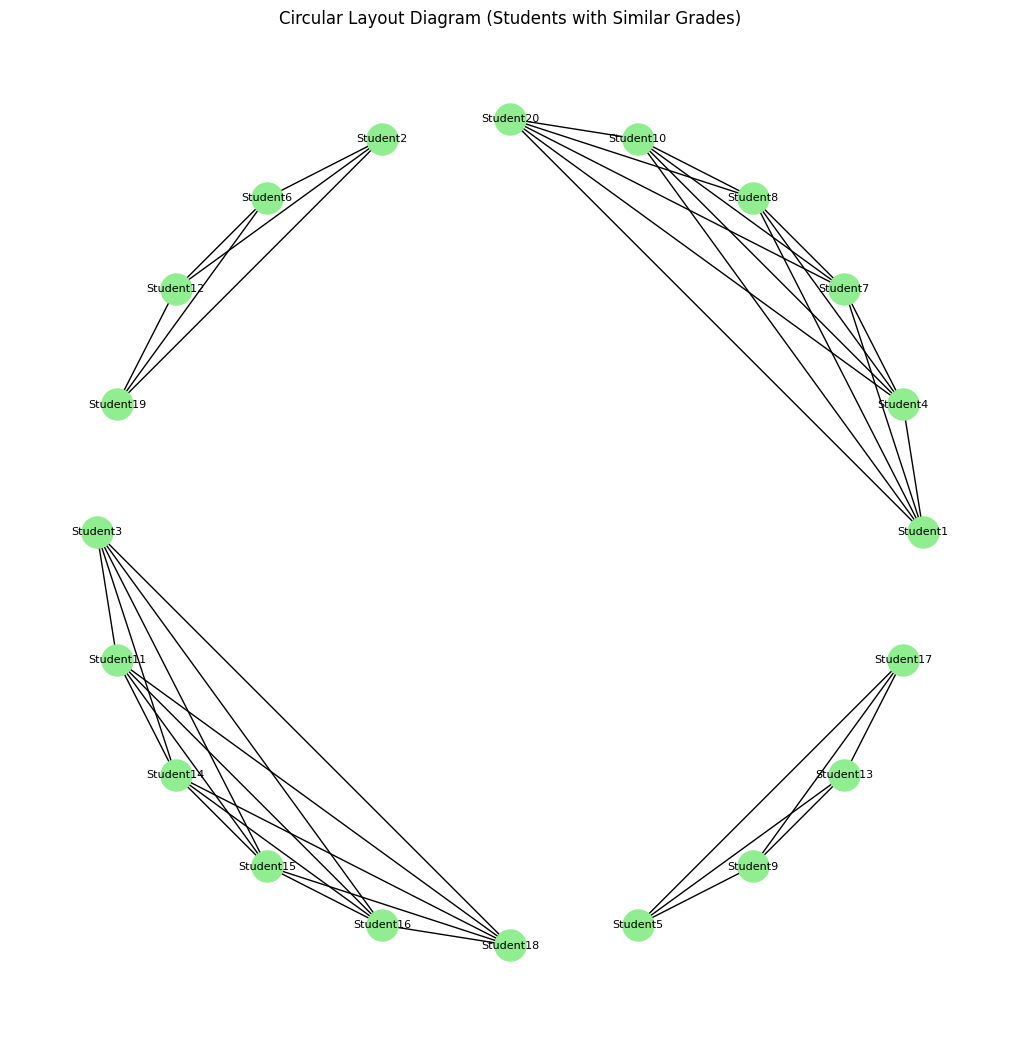

In [ ]:
plt.figure(figsize=(10, 10))
pos_circular = nx.circular_layout(G)
nx.draw(G, pos_circular, with_labels=True, node_size=500, node_color='lightgreen', font_size=8, font_color='black')
plt.title("Circular Layout Diagram (Students with Similar Grades)")
plt.show()

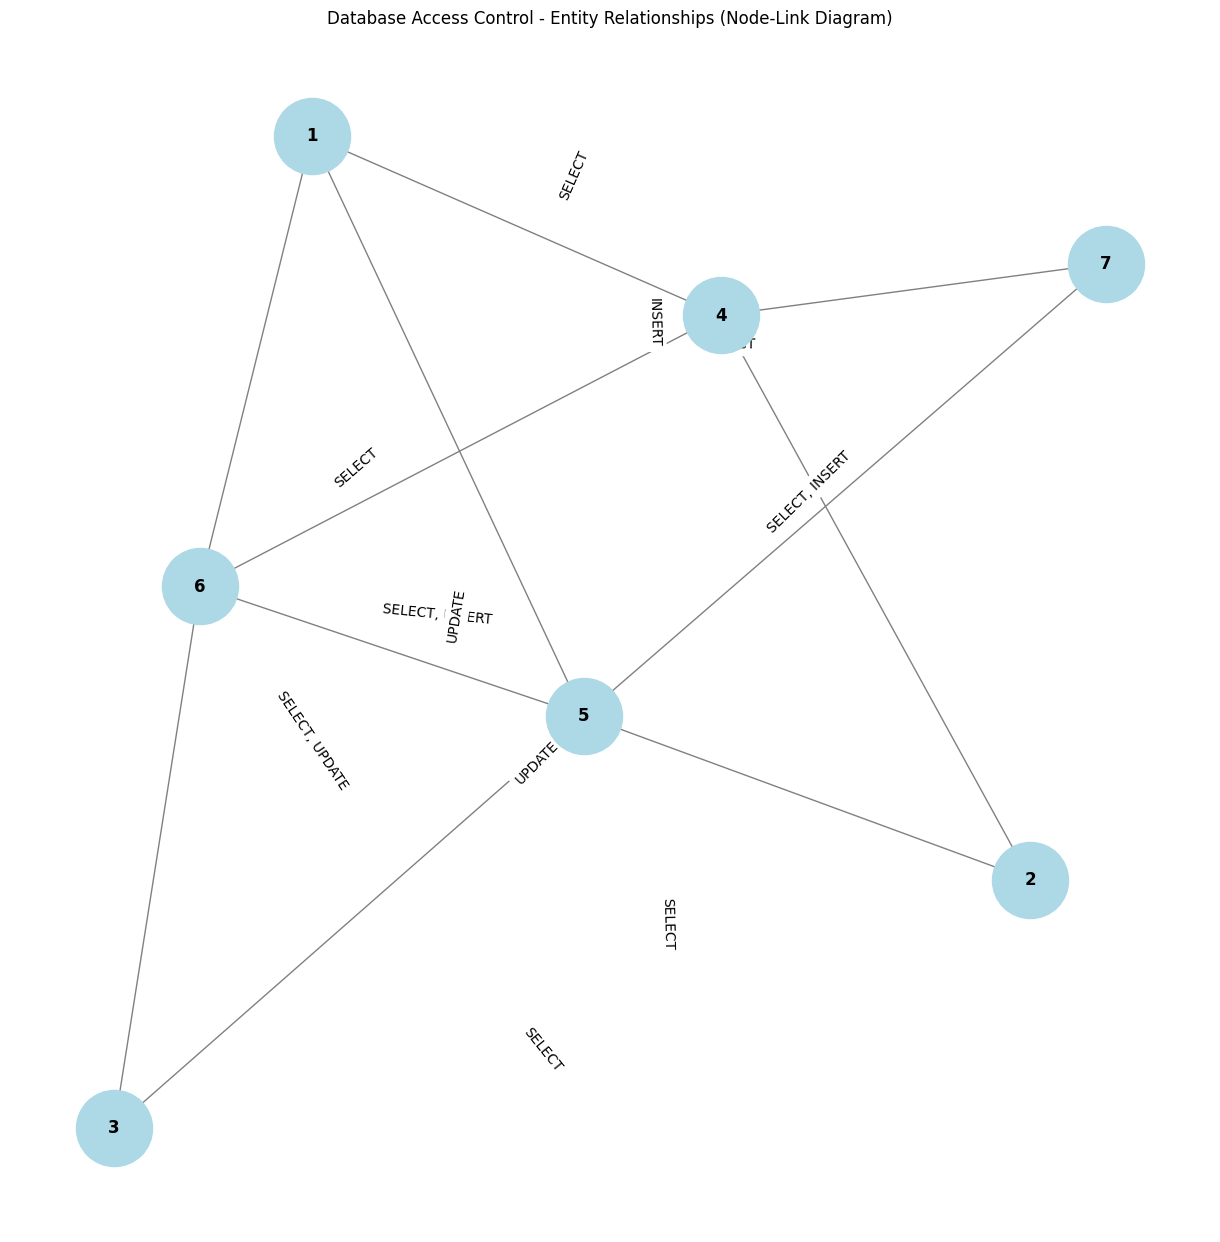

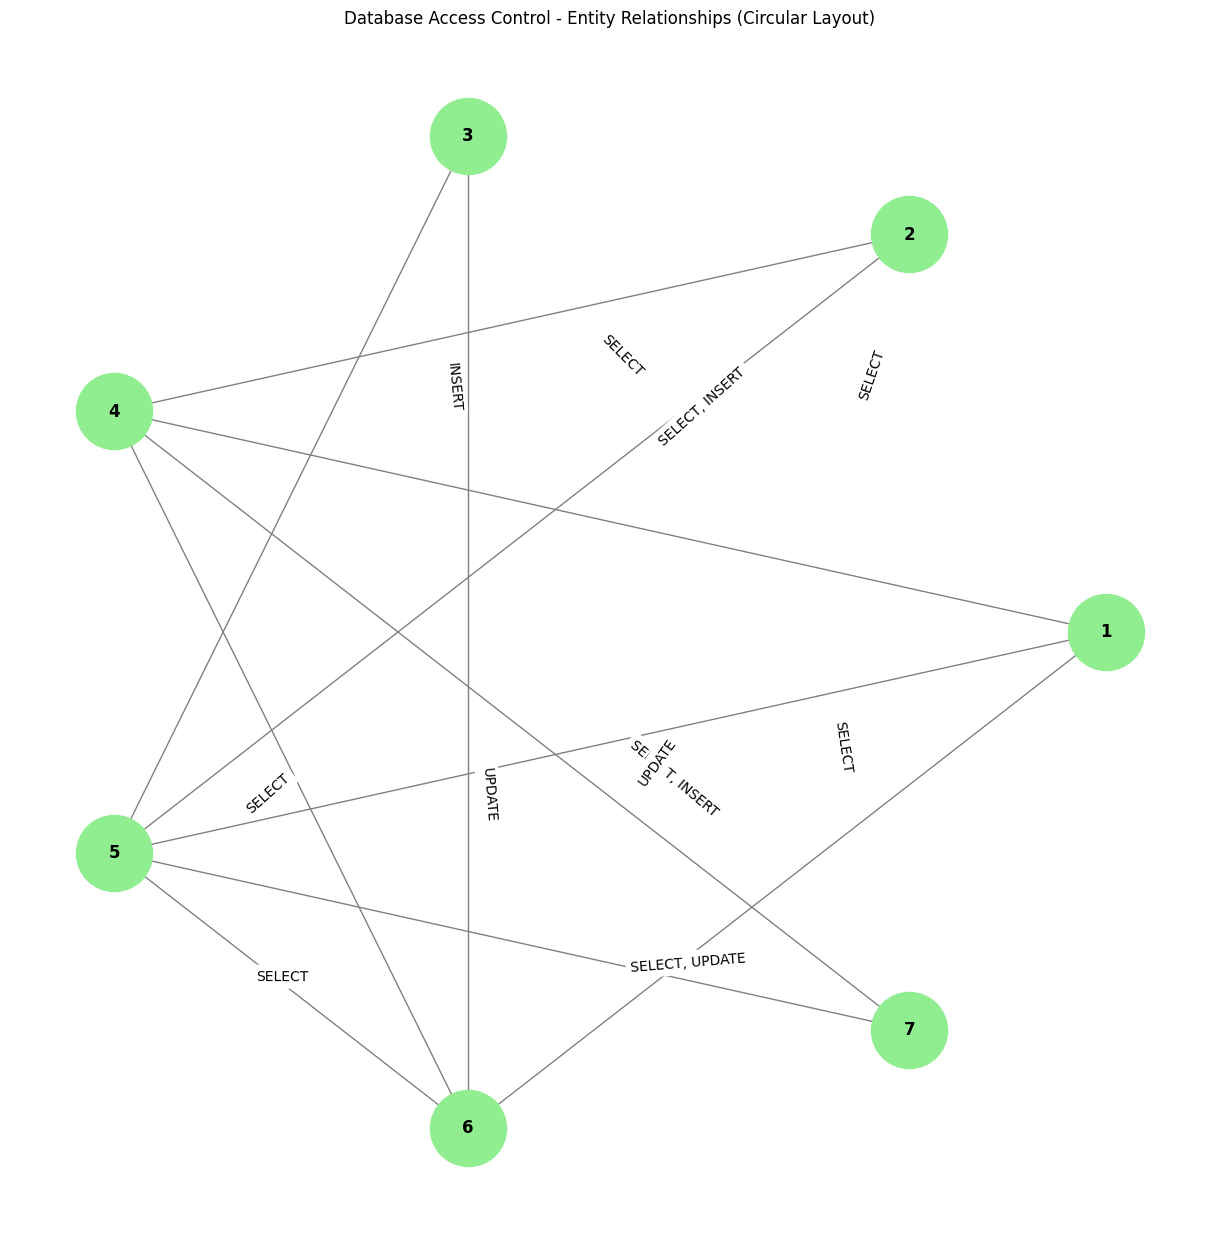

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a new graph object
G = nx.Graph()

# Add nodes (entities in the database) with attributes
entities = [
    (1, {"name": "Alice", "type": "User", "role": "Admin", "database": "HR_DB"}),
    (2, {"name": "Bob", "type": "User", "role": "Manager", "database": "HR_DB"}),
    (3, {"name": "Charlie", "type": "User", "role": "Employee", "database": "HR_DB"}),
    (4, {"name": "SalesTable", "type": "Table", "role": "N/A", "database": "HR_DB"}),
    (5, {"name": "Employees", "type": "Table", "role": "N/A", "database": "HR_DB"}),
    (6, {"name": "Payroll", "type": "Table", "role": "N/A", "database": "HR_DB"}),
    (7, {"name": "ReportsTable", "type": "Table", "role": "N/A", "database": "Reports_DB"})
]

# Add entities as nodes to the graph
for entity in entities:
    G.add_node(entity[0], **entity[1])

# Define the relationships (edges) with relationship types (access permissions)
relationships = [
    (1, 4, "SELECT"),
    (1, 5, "SELECT, INSERT"),
    (1, 6, "SELECT, UPDATE"),
    (2, 4, "SELECT"),
    (2, 5, "SELECT, INSERT"),
    (3, 5, "SELECT"),
    (3, 6, "SELECT"),
    (4, 7, "SELECT"),
    (5, 7, "INSERT"),
    (6, 4, "UPDATE"),
    (6, 5, "UPDATE")
]
for relationship in relationships:
    G.add_edge(relationship[0], relationship[1], relationship=relationship[2])
plt.figure(figsize=(12, 12))
edge_labels = nx.get_edge_attributes(G, 'relationship')
nx.draw(G, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)
plt.title("Database Access Control - Entity Relationships (Node-Link Diagram)")
plt.show()
plt.figure(figsize=(12, 12))
nx.draw_circular(G, with_labels=True, node_size=3000, node_color='lightgreen', font_size=12, font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)
plt.title("Database Access Control - Entity Relationships (Circular Layout)")
plt.show()


Text(0.5, 1.0, 'Collaboration Network - Entity Relationships (Node-Link Diagram)')

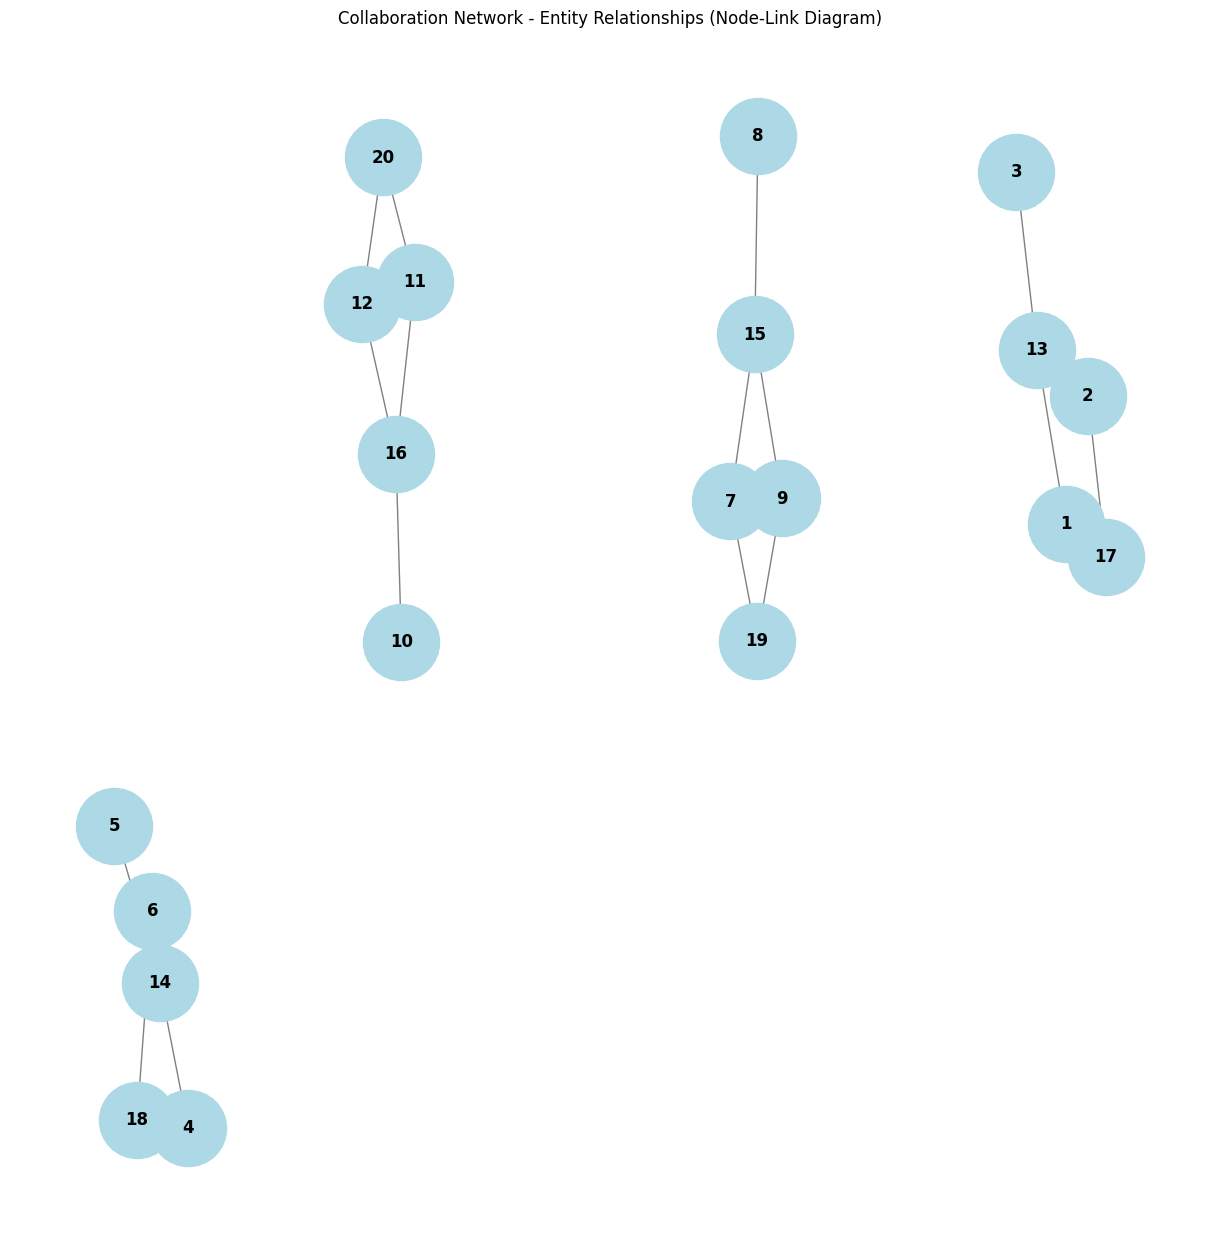

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a new graph object
G = nx.Graph()

# Add nodes (users and projects) with attributes
entities = [
    (1, {"name": "Alice", "type": "User", "role": "Admin", "project": "Project A"}),
    (2, {"name": "Bob", "type": "User", "role": "Member", "project": "Project A"}),
    (3, {"name": "Charlie", "type": "User", "role": "Contributor", "project": "Project A"}),
    (4, {"name": "David", "type": "User", "role": "Member", "project": "Project B"}),
    (5, {"name": "Emma", "type": "User", "role": "Admin", "project": "Project B"}),
    (6, {"name": "Fiona", "type": "User", "role": "Contributor", "project": "Project B"}),
    (7, {"name": "George", "type": "User", "role": "Member", "project": "Project C"}),
    (8, {"name": "Hannah", "type": "User", "role": "Admin", "project": "Project C"}),
    (9, {"name": "Ian", "type": "User", "role": "Contributor", "project": "Project C"}),
    (10, {"name": "Jack", "type": "User", "role": "Member", "project": "Project D"}),
    (11, {"name": "Karen", "type": "User", "role": "Admin", "project": "Project D"}),
    (12, {"name": "Leo", "type": "User", "role": "Contributor", "project": "Project D"}),
    (13, {"name": "Project A", "type": "Project", "role": "N/A", "project": "N/A"}),
    (14, {"name": "Project B", "type": "Project", "role": "N/A", "project": "N/A"}),
    (15, {"name": "Project C", "type": "Project", "role": "N/A", "project": "N/A"}),
    (16, {"name": "Project D", "type": "Project", "role": "N/A", "project": "N/A"}),
    (17, {"name": "Marketing Team", "type": "Team", "role": "N/A", "project": "N/A"}),
    (18, {"name": "Research Team", "type": "Team", "role": "N/A", "project": "N/A"}),
    (19, {"name": "Development Team", "type": "Team", "role": "N/A", "project": "N/A"}),
    (20, {"name": "Sales Team", "type": "Team", "role": "N/A", "project": "N/A"})
]

# Add entities as nodes to the graph
for entity in entities:
    G.add_node(entity[0], **entity[1])

# Define the relationships (edges) with relationship types
relationships = [
    (1, 13, "Admin of"),
    (2, 13, "Member of"),
    (3, 13, "Contributor to"),
    (4, 14, "Member of"),
    (5, 14, "Admin of"),
    (6, 14, "Contributor to"),
    (7, 15, "Member of"),
    (8, 15, "Admin of"),
    (9, 15, "Contributor to"),
    (10, 16, "Member of"),
    (11, 16, "Admin of"),
    (12, 16, "Contributor to"),
    (1, 17, "Collaborates on"),
    (2, 17, "Collaborates on"),
    (4, 18, "Collaborates on"),
    (6, 18, "Collaborates on"),
    (7, 19, "Collaborates on"),
    (9, 19, "Collaborates on"),
    (11, 20, "Collaborates on"),
    (12, 20, "Collaborates on")
]

# Add the relationships (edges) to the graph
for relationship in relationships:
    G.add_edge(relationship[0], relationship[1], relationship=relationship[2])

# Visualize the graph (Node-Link Diagram)
plt.figure(figsize=(12, 12))

# Get the labels for relationships (edge attributes)
edge_labels = nx.get_edge_attributes(G, 'relationship')

# Draw nodes and edges
nx.draw(G, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color='gray')

# Draw edge labels
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)

# Set the title
plt.title("Collaboration Network - Entity Relationships (Node-Link Diagram)")

# Display


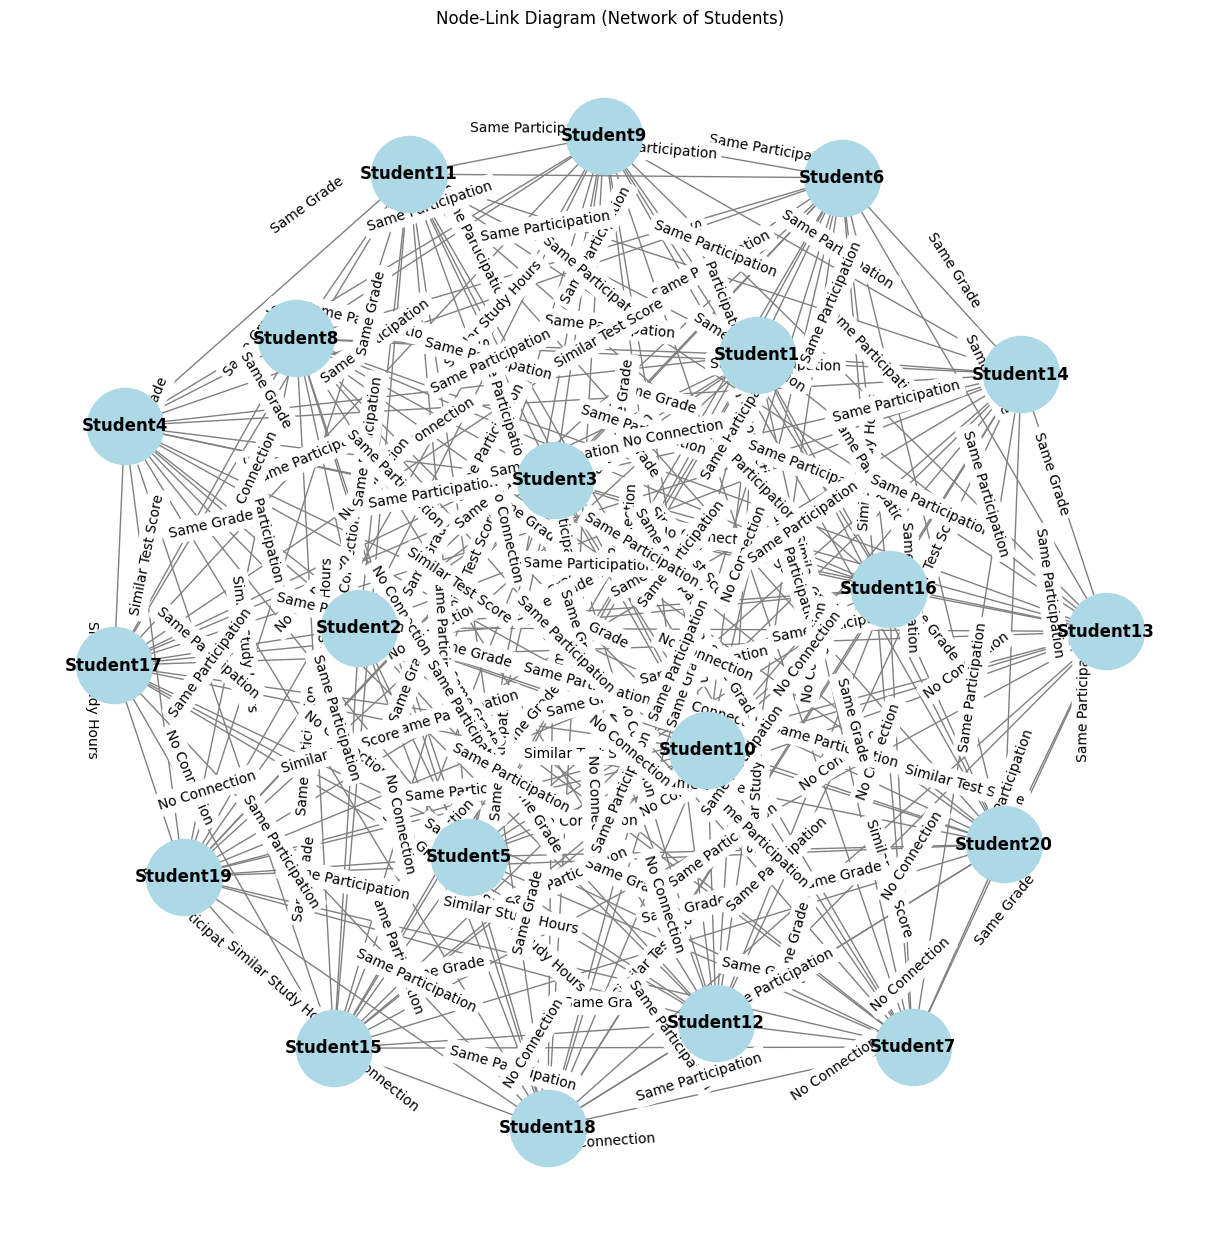

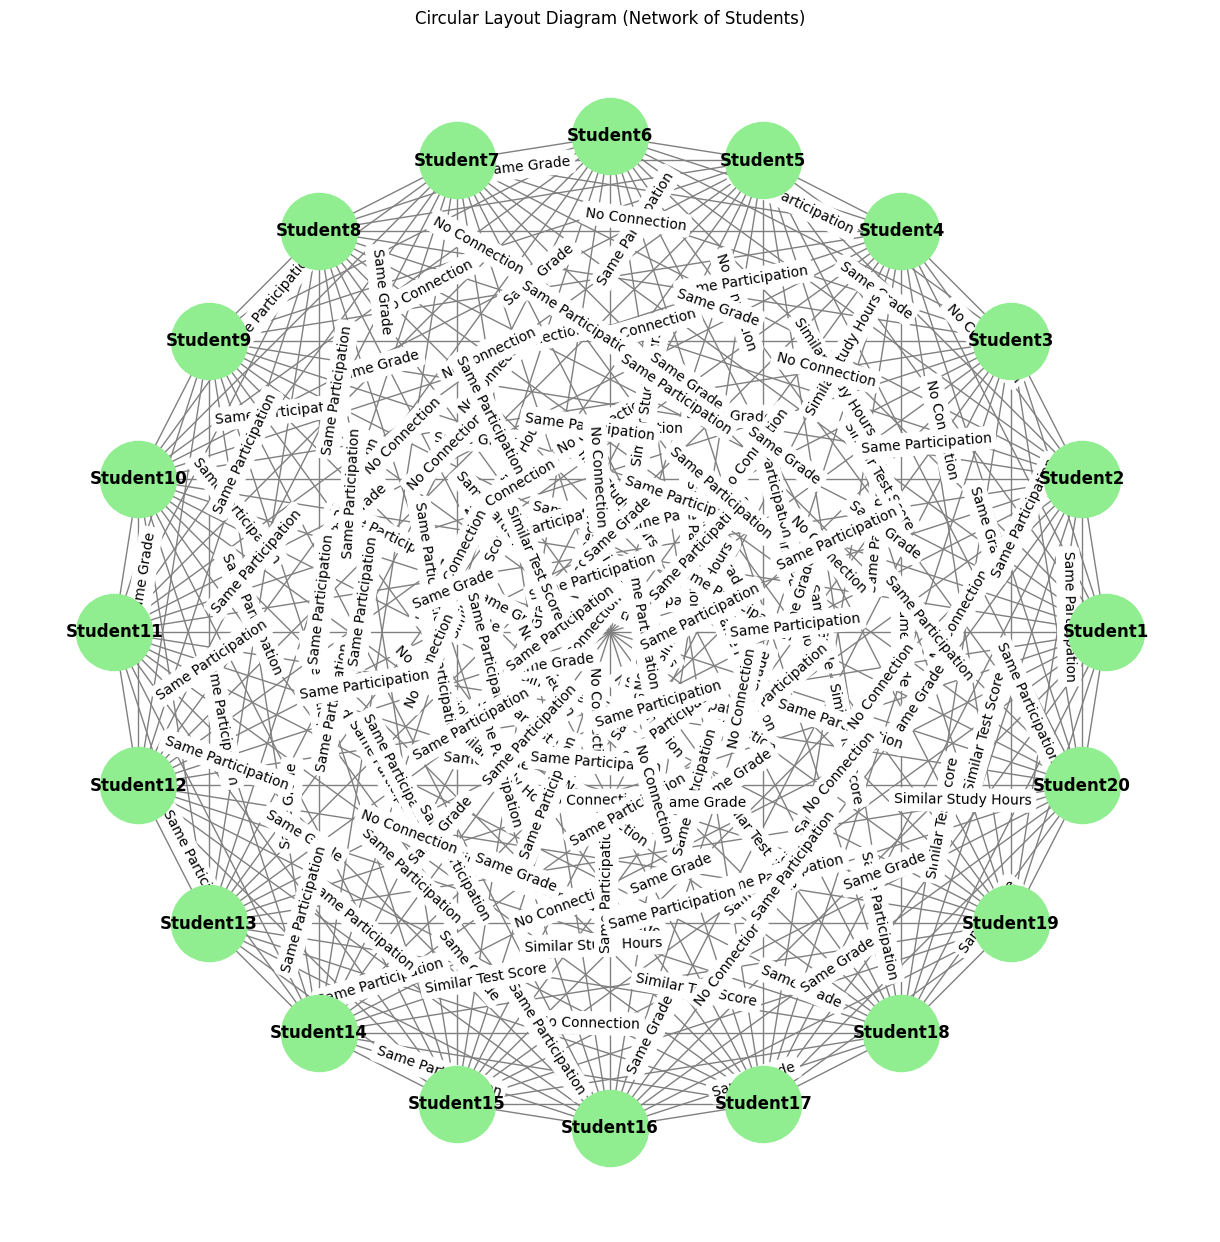

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Create the original DataFrame
data = pd.DataFrame({
    'Name': [f'Student{i}' for i in range(1, 21)],  # Nominal
    'Age': np.random.randint(18, 25, 20),  # Ratio (Continuous)
    'Gender': np.random.choice(['Male', 'Female'], 20),  # Nominal
    'Grade': np.random.choice(['A', 'B', 'C', 'D'], 20),  # Ordinal
    'Test_Score': np.random.randint(40, 101, 20),  # Interval
    'Attendance (%)': np.random.randint(60, 101, 20),  # Ratio (Continuous)
    'Study_Hours': np.random.uniform(1, 10, 20).round(1),  # Ratio (Continuous)
    'Participation': np.random.choice(['Yes', 'No'], 20),  # Nominal
    'Projects_Completed': np.random.randint(1, 6, 20),  # Ratio (Discrete)
    'Satisfaction_Score': np.random.choice([1, 2, 3, 4, 5], 20)  # Ordinal
})

# Generate a new column for edge type based on relationships between students
# For simplicity, we will consider the following relationships for the edge names:
# 1. Same Grade
# 2. Same Participation
# 3. Similar Test Score (within a range of +/- 5)
# 4. Similar Study Hours (within a range of +/- 1 hour)

def get_edge_type(row1, row2):
    if row1['Grade'] == row2['Grade']:
        return 'Same Grade'
    elif row1['Participation'] == row2['Participation']:
        return 'Same Participation'
    elif abs(row1['Test_Score'] - row2['Test_Score']) <= 5:
        return 'Similar Test Score'
    elif abs(row1['Study_Hours'] - row2['Study_Hours']) <= 1:
        return 'Similar Study Hours'
    return 'No Connection'

# Create an empty list to store the edges
edges = []

# Create edges between all pairs of students
for i in range(len(data)):
    for j in range(i + 1, len(data)):
        # Get the edge type between student i and student j
        edge_type = get_edge_type(data.iloc[i], data.iloc[j])
        # Add the edge between these two students with the corresponding edge type
        edges.append([data.iloc[i]['Name'], data.iloc[j]['Name'], edge_type])

# Convert the list of edges into a DataFrame
edges_df = pd.DataFrame(edges, columns=['Source', 'Target', 'Edge_Type'])

# Create a graph object
G = nx.Graph()

# Add nodes (students)
for _, row in data.iterrows():
    G.add_node(row['Name'], **row.to_dict())

# Add edges (relationships)
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], relationship=row['Edge_Type'])

# a. Node-Link Diagram (Spring Layout)

plt.figure(figsize=(12, 12))

# Get edge labels (relationship types)
edge_labels = nx.get_edge_attributes(G, 'relationship')

# Draw the graph using spring layout
nx.draw(G, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color='gray')

# Draw edge labels
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)

# Set the title and display the Node-Link Diagram
plt.title("Node-Link Diagram (Network of Students)")
plt.show()


# b. Circular Layout Diagram

plt.figure(figsize=(12, 12))

# Draw the graph using a circular layout
nx.draw_circular(G, with_labels=True, node_size=3000, node_color='lightgreen', font_size=12, font_weight='bold', edge_color='gray')

# Draw edge labels
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)

# Set the title and display the Circular Layout Diagram
plt.title("Circular Layout Diagram (Network of Students)")
plt.show()


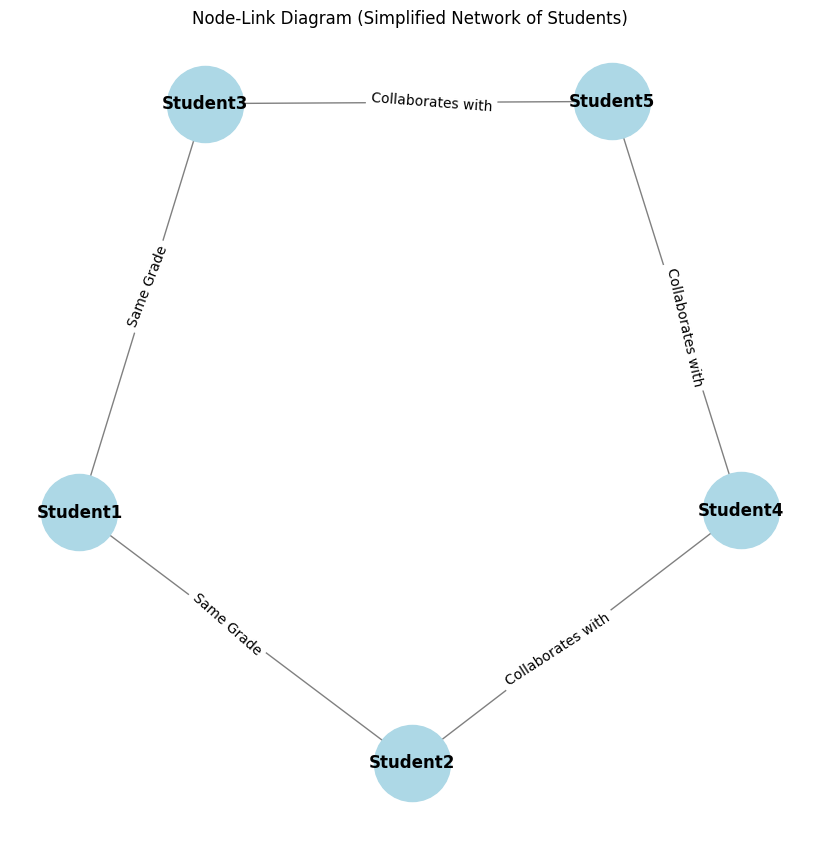

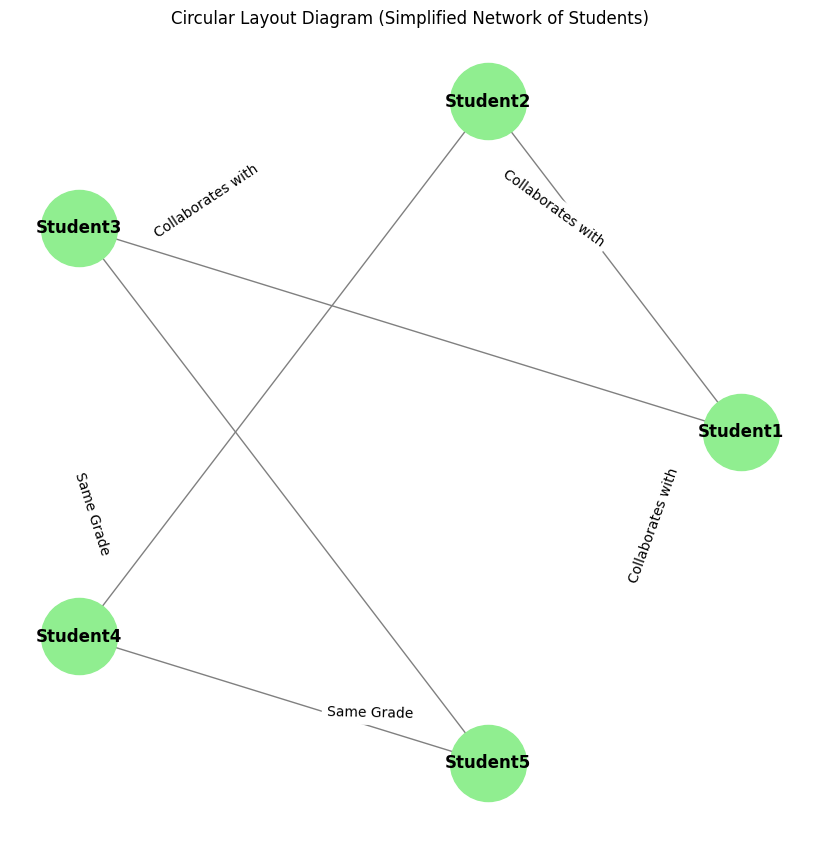

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
data = pd.DataFrame({
    'Name': ['Student1', 'Student2', 'Student3', 'Student4', 'Student5'],  # Nominal
    'Grade': ['A', 'B', 'A', 'C', 'B'],  # Ordinal (Grade)
    'Projects_Completed': [3, 2, 3, 1, 2],  # Discrete (Projects completed)
})

edges = [
    ('Student1', 'Student2', 'Collaborates with'),
    ('Student1', 'Student3', 'Same Grade'),
    ('Student2', 'Student4', 'Collaborates with'),
    ('Student3', 'Student5', 'Same Grade'),
    ('Student4', 'Student5', 'Collaborates with')
]

# Create a graph object
G = nx.Graph()

# Add nodes (students)
for _, row in data.iterrows():
    G.add_node(row['Name'], grade=row['Grade'], projects=row['Projects_Completed'])

# Add edges (relationships between students)
for edge in edges:
    G.add_edge(edge[0], edge[1], relationship=edge[2])

# a. Node-Link Diagram (Spring Layout)

plt.figure(figsize=(8, 8))

# Draw the graph using spring layout
nx.draw(G, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color='gray')

# Draw edge labels (relationships)
edge_labels = nx.get_edge_attributes(G, 'relationship')
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)

# Set title
plt.title("Node-Link Diagram (Simplified Network of Students)")

# Show plot
plt.show()

# b. Circular Layout Diagram

plt.figure(figsize=(8, 8))

# Draw the graph using a circular layout
nx.draw_circular(G, with_labels=True, node_size=3000, node_color='lightgreen', font_size=12, font_weight='bold', edge_color='gray')

# Draw edge labels (relationships)
nx.draw_networkx_edge_labels(G, pos=nx.spring_layout(G), edge_labels=edge_labels)

# Set title
plt.title("Circular Layout Diagram (Simplified Network of Students)")

# Show plot
plt.show()


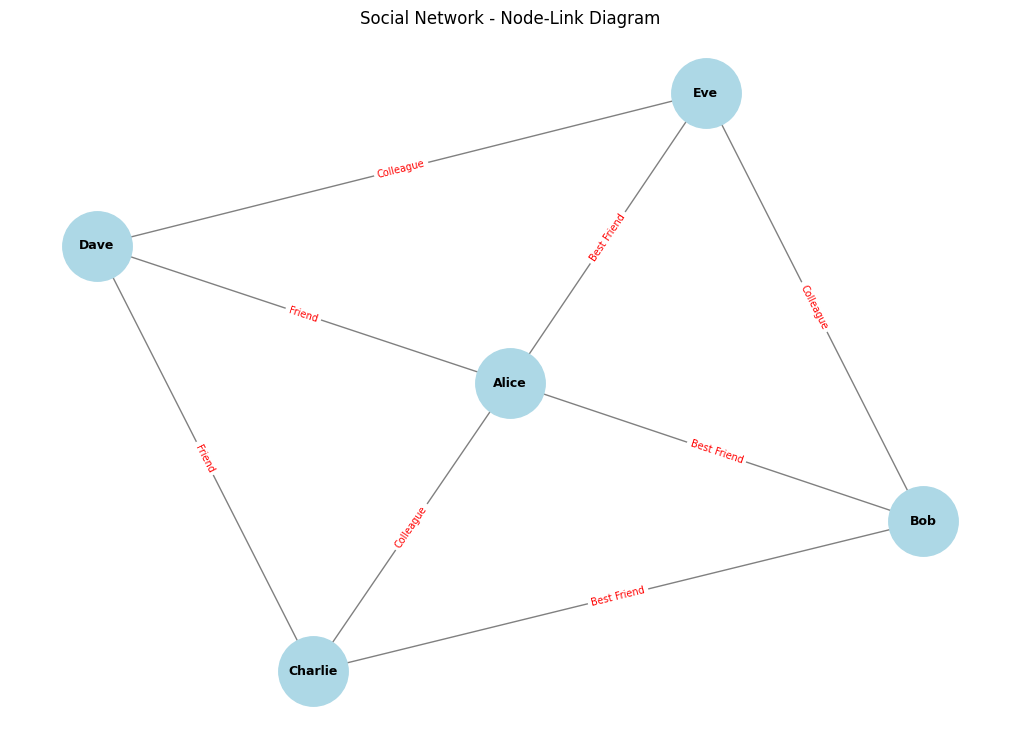

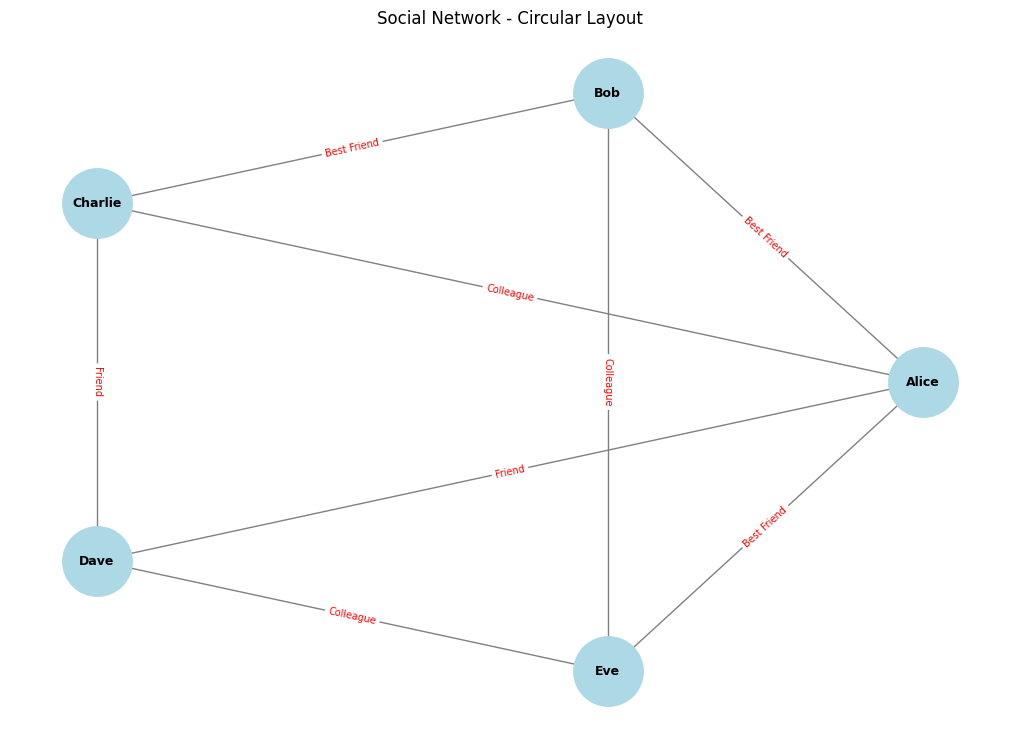

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
data = {
    "User1": ["Alice", "Alice", "Bob", "Charlie", "Dave", "Alice", "Bob", "Dave"],
    "User2": ["Bob", "Charlie", "Charlie", "Dave", "Eve", "Eve", "Eve", "Alice"],
    "ConnectionType": ["Best Friend", "Colleague", "Best Friend", "Friend", "Colleague", "Best Friend", "Colleague", "Friend"]
}
df = pd.DataFrame(data)
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["User1"], row["User2"], label=row["ConnectionType"])
pos_spring = nx.spring_layout(G, seed=42)  # Node-Link Layout
pos_circular = nx.circular_layout(G)  # Circular Layout
def draw_graph(pos, title):
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=9, font_weight="bold")
    edge_labels = {(row["User1"], row["User2"]): row["ConnectionType"] for _, row in df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='red')
    plt.title(title)
    plt.show()
draw_graph(pos_spring, "Social Network - Node-Link Diagram")
draw_graph(pos_circular, "Social Network - Circular Layout")


In [ ]:
import pandas as pd

# Define the dataset for the social network
data = {
    "User1": ["Alice", "Alice", "Alice", "Alice", "Bob", "Bob", "Bob", "Charlie", "Charlie", "Dave",
              "Alice", "Bob", "Charlie", "Dave", "Eve", "Alice", "Bob", "Charlie", "Dave", "Eve", "Frank"],
    "User2": ["Bob", "Charlie", "Dave", "Eve", "Charlie", "Dave", "Eve", "Dave", "Eve", "Eve",
              "Frank", "Frank", "Frank", "Frank", "Frank", "Grace", "Grace", "Grace", "Grace", "Grace", "Grace"],
    "ConnectionType": ["Best Friend", "Colleague", "Friend", "Best Friend", "Best Friend", "Friend", "Colleague",
                       "Colleague", "Friend", "Best Friend", "Colleague", "Best Friend", "Colleague", "Friend",
                       "Colleague", "Best Friend", "Colleague", "Friend", "Best Friend", "Colleague", "Friend"]
}

# Convert the dataset to a DataFrame
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv("social_network.csv", index=False)

print("Dataset saved as 'social_network.csv'")


Dataset saved as 'social_network.csv'


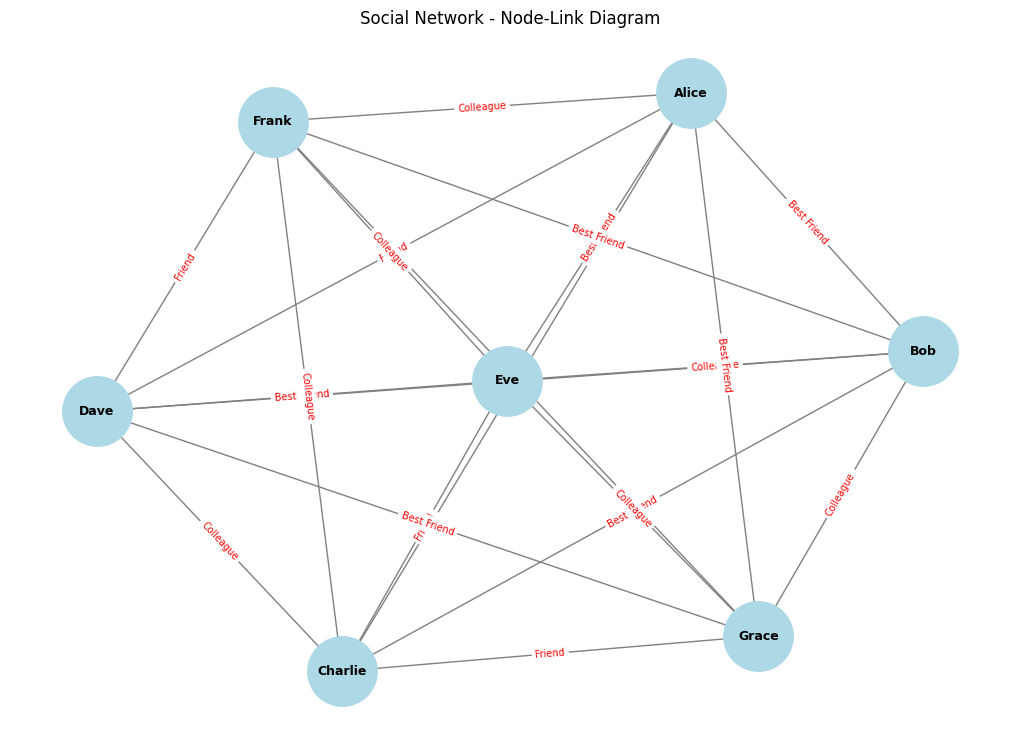

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
df = pd.read_csv("social_network.csv")
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["User1"], row["User2"], label=row["ConnectionType"])
pos_spring = nx.spring_layout(G, seed=42)
def draw_node_link_graph():
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos_spring, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=9, font_weight="bold")
    edge_labels = {(row["User1"], row["User2"]): row["ConnectionType"] for _, row in df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos_spring, edge_labels=edge_labels, font_size=7, font_color='red')
    plt.title("Social Network - Node-Link Diagram")
    plt.show()
draw_node_link_graph()

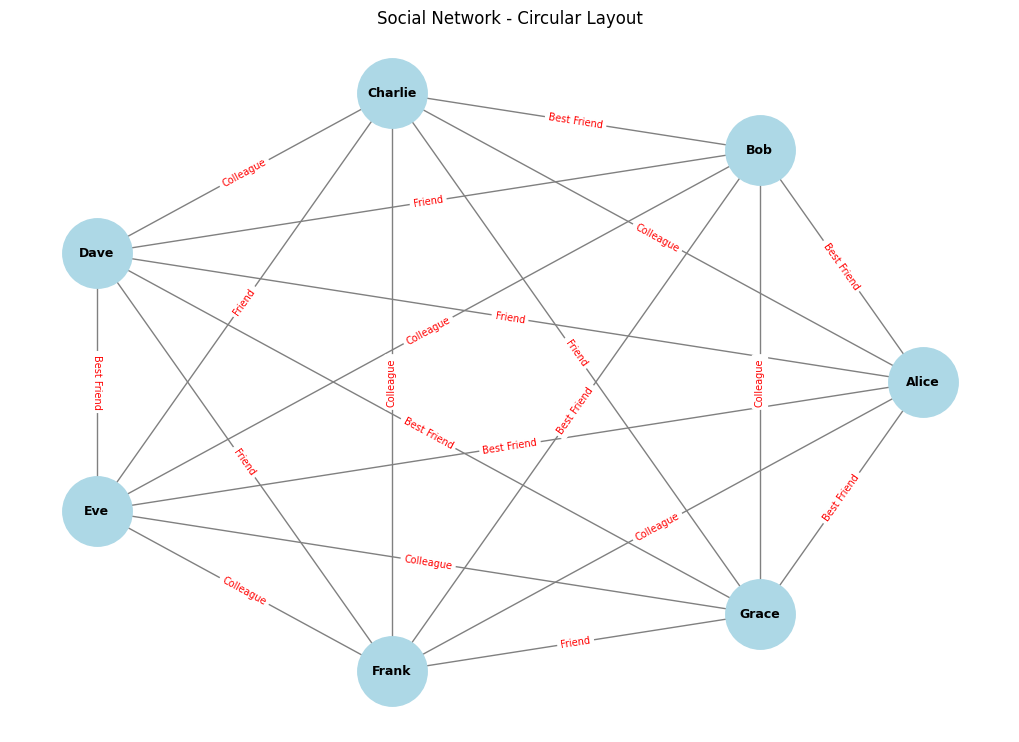

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
df = pd.read_csv("social_network.csv")
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["User1"], row["User2"], label=row["ConnectionType"])
pos_circular = nx.circular_layout(G)
def draw_circular_layout_graph():
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos_circular, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=9, font_weight="bold")
    edge_labels = {(row["User1"], row["User2"]): row["ConnectionType"] for _, row in df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos_circular, edge_labels=edge_labels, font_size=7, font_color='red')
    plt.title("Social Network - Circular Layout")
    plt.show()
draw_circular_layout_graph()


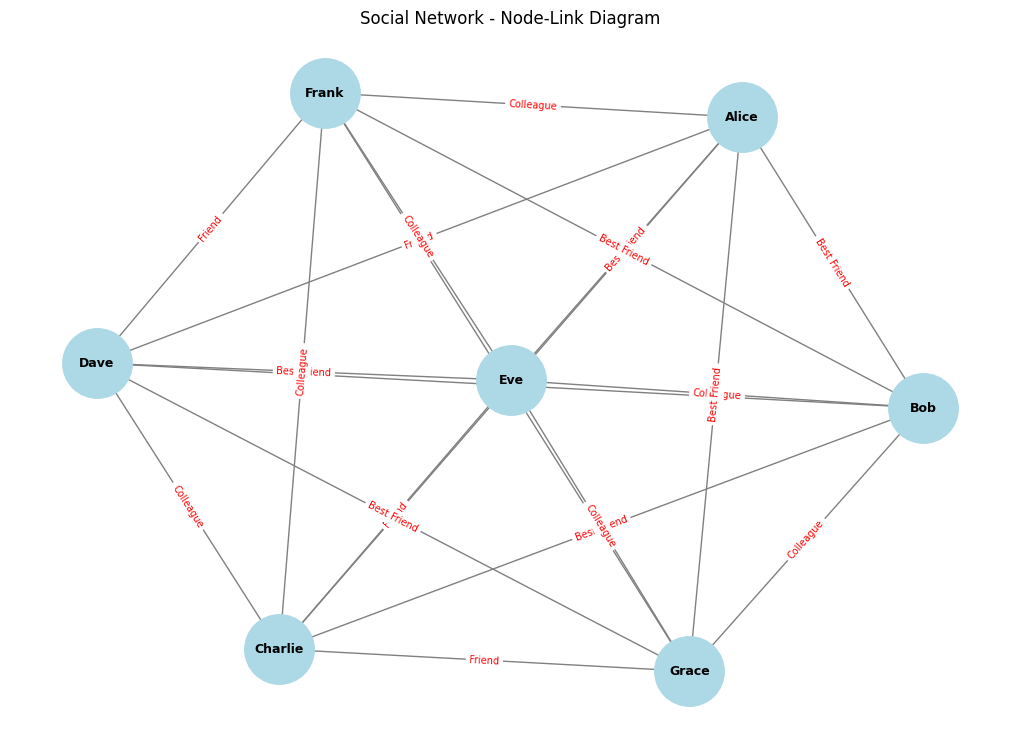

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
df = pd.read_csv("social_network.csv")
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row["User1"], row["User2"], label=row["ConnectionType"])
pos_spring = nx.spring_layout(G, k=0.5, seed=42)
def draw_node_link_graph():
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos_spring, with_labels=True, node_color='lightblue', edge_color='gray', node_size=2500, font_size=9, font_weight="bold")
    edge_labels = {(row["User1"], row["User2"]): row["ConnectionType"] for _, row in df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos_spring, edge_labels=edge_labels, font_size=7, font_color='red')
    plt.title("Social Network - Node-Link Diagram")
    plt.show()
draw_node_link_graph()

In [ ]:
import pandas as pd
import plotly.express as px
data = {
    "User1": ["Alice", "Alice", "Alice", "Alice", "Bob", "Bob", "Bob", "Charlie", "Charlie", "Dave",
              "Alice", "Bob", "Charlie", "Dave", "Eve", "Alice", "Bob", "Charlie", "Dave", "Eve", "Frank"],
    "User2": ["Bob", "Charlie", "Dave", "Eve", "Charlie", "Dave", "Eve", "Dave", "Eve", "Eve",
              "Frank", "Frank", "Frank", "Frank", "Frank", "Grace", "Grace", "Grace", "Grace", "Grace", "Grace"],
    "ConnectionType": ["Best Friend", "Colleague", "Friend", "Best Friend", "Best Friend", "Friend", "Colleague",
                       "Colleague", "Friend", "Best Friend", "Colleague", "Best Friend", "Colleague", "Friend",
                       "Colleague", "Best Friend", "Colleague", "Friend", "Best Friend", "Colleague", "Friend"]
}

df = pd.DataFrame(data)
fig = px.sunburst(
    df,
    path=["User1", "ConnectionType", "User2"],
    values=None,  # Treat each row as equal
    title="🌞 Social Network Sunburst Visualization",
    color="User1",
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.show()


In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 51.8 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs

# Load country boundaries
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
world['name'] = world['NAME'].replace('United States of America', 'United States')

# Sample dataset with GDP
data = {
    "Country": ["India", "United States", "China", "Russia", "Brazil", "Germany", "France", "Japan", "United Kingdom", "Canada"],
    "GDP": [3.73, 25.46, 17.73, 1.78, 1.92, 4.22, 3.05, 4.94, 3.19, 2.14]  # In trillions
}
df = pd.DataFrame(data)

# Merge with GeoDataFrame
merged = world.merge(df, left_on='name', right_on='Country', how='inner')

# Get centroids for placing rectangles
merged['lon'] = merged['geometry'].centroid.x
merged['lat'] = merged['geometry'].centroid.y

# Normalize GDP for rectangle sizes
max_gdp = merged['GDP'].max()
merged['size'] = merged['GDP'] / max_gdp * 5  # Scale sizes

# Plot with cartopy
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_title("Rectangular Cartogram: Country GDP Representation", fontsize=16, pad=20)

# Draw rectangles
for _, row in merged.iterrows():
    width = height = row['size']
    rect = mpatches.Rectangle((row['lon'] - width / 2, row['lat'] - height / 2),
                              width, height,
                              facecolor=plt.cm.YlOrRd(row['GDP'] / max_gdp),
                              edgecolor='black', transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    ax.text(row['lon'], row['lat'], row['Country'], fontsize=8,
            ha='center', va='center', transform=ccrs.PlateCarree(), color='black')

# Add legend manually
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=merged['GDP'].min(), vmax=merged['GDP'].max()))
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5, label="GDP (Trillions USD)")

plt.tight_layout()
plt.show()


<ipython-input-5-cc601bfe68be>:22: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


<ipython-input-5-cc601bfe68be>:23: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


<ipython-input-5-cc601bfe68be>:49: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip



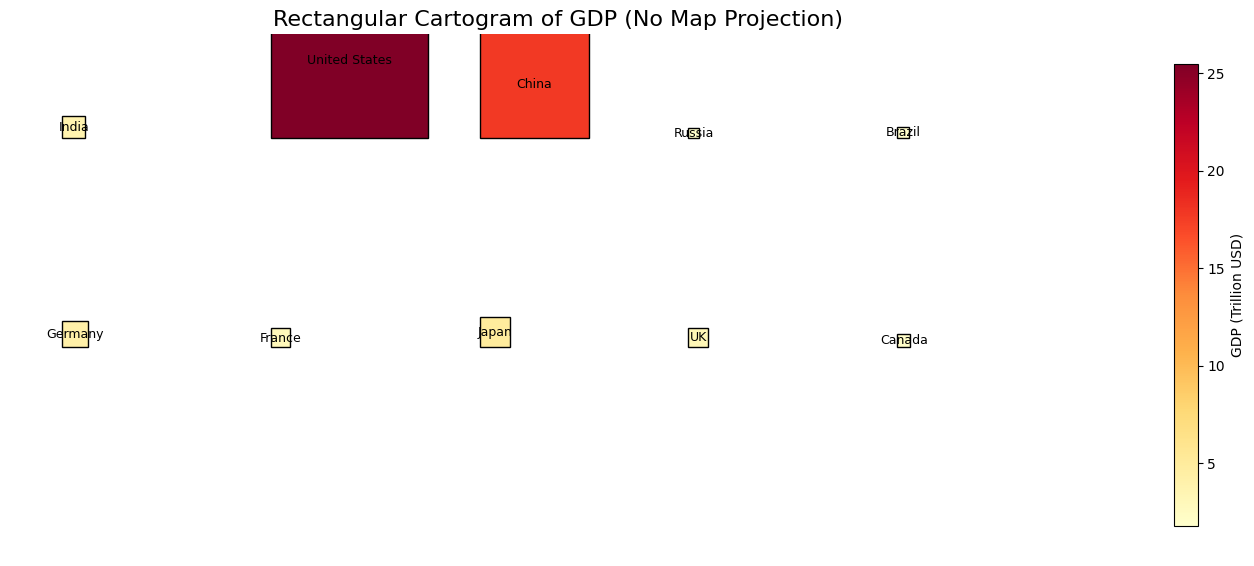

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Sample data
data = {
    "Country": ["India", "United States", "China", "Russia", "Brazil", "Germany", "France", "Japan", "UK", "Canada"],
    "GDP": [3.73, 25.46, 17.73, 1.78, 1.92, 4.22, 3.05, 4.94, 3.19, 2.14]  # Trillion USD
}
df = pd.DataFrame(data)

# Normalize GDP to use as rectangle size
df['Size'] = df['GDP'] / df['GDP'].max() * 3

# Arrange rectangles in a grid
rows = 2
cols = 5
x_spacing = 4
y_spacing = 4

positions = [(i % cols * x_spacing, -(i // cols * y_spacing)) for i in range(len(df))]
df['x'], df['y'] = zip(*positions)

# Plot rectangles as cartogram
fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.cm.YlOrRd
norm = plt.Normalize(df['GDP'].min(), df['GDP'].max())

for i, row in df.iterrows():
    rect = mpatches.Rectangle(
        (row['x'], row['y']),
        row['Size'], row['Size'],
        facecolor=cmap(norm(row['GDP'])),
        edgecolor='black'
    )
    ax.add_patch(rect)
    ax.text(
        row['x'] + row['Size'] / 2,
        row['y'] + row['Size'] / 2,
        row['Country'],
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, label='GDP (Trillion USD)')

ax.set_xlim(-1, cols * x_spacing)
ax.set_ylim(-rows * y_spacing, 2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Rectangular Cartogram of GDP (No Map Projection)", fontsize=16)
plt.tight_layout()
plt.show()
